# Spicerack - Recipe Recommender
### **DS Club Project - Spring 2026**


**SpiceRack** is a recipe recommendation system that takes the spices in your pantry and finds recipes you can make. It learns which spices are rare and distinctive (saffron, galangal) vs common and uninformative (salt, pepper); the results are driven by what makes your pantry unique.


### - **Features**
* Recommends recipes based on your spice pantry using a trained K-Means model
* Hearts recipes to save them to your personal collection
* Suggests spices to buy that would unlock the most new recipes
* Scans barcodes on spice jars to add spices automatically
* Validates spice input  only accepts known canonical spices from a 179-spice vocabulary
* Modal popups with full ingredients, directions, and a photo from Unsplash


###  - **Project Resources**
* Main Repository: [GitHub - SpiceRack Core](https://github.com/laniel123/DS-Club-Project-Showcase-SpiceRack)
* Web Implementation: [GitHub - SpiceRack UI](https://github.com/Luke-B-Mal/SpiceRack-website)
* Data Source: [Kaggle Data](https://www.kaggle.com/datasets/paultimothymooney/recipenlg/data)
* Restrictions Logic: [GitHub - Recipes-Restrictions](https://github.com/austinpak/Recipes-Restrictions)
* Image API: [Unsplash](https://unsplash.com/)
* Barcode API: [Open Food Facts](https://world.openfoodfacts.org/)



---
## - Change your inputs here

This is the only cell you need to touch. Edit your pantry, then run all cells. use for the initial testing of the model within this notebook.

If you put something in must-use that isn't in your pantry, it gets added automatically.
If a spice isn't recognized it just gets skipped with a warning.

In [65]:
# change these two lists and run everything

# spices you actually have right now
MY_PANTRY = [
    "garlic",
    "cumin",
    "paprika",
    "chili powder",
    "oregano",
    "black pepper",
    "salt",
    "cinnamon",
    "ginger",
]

# spices that MUST show up in every recipe we recommend
# leave as [] if you dont care
MUST_USE = [
    "cumin",
    "garlic",
]

# path to your original csv file downloaded on kaggle 
CSV_PATH = "cookingdataset/RecipeNLG_dataset.csv"

# how many recipes to load - lower this if its running slow
SAMPLE_SIZE = None  # set to None to load all, or a number like 10000 for a sample

---
## - Imports and setup
Run this once, dont touch it

In [66]:
import re
import warnings
import pandas as pd
import numpy as np
import joblib
import time
from sklearn.decomposition import NMF
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import pairwise_distances

# pulling all our spice data from the external file
# spice_data.py needs to be in the same folder as this notebook
from spice_data_v2 import SPICES, ALIASES, CANONICAL_SPICES, FLAVOR_PROFILES, REGION_PROFILES

print(f"loaded {len(CANONICAL_SPICES)} spices, {len(FLAVOR_PROFILES)} flavor profiles, {len(REGION_PROFILES)} regions")

loaded 180 spices, 15 flavor profiles, 16 regions


In [67]:
# helper functions used throughout

from spice_data_v2 import SPICES, ALIASES, CANONICAL_SPICES

def clean(s) -> str:
    # lowercase and strip weird characters
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"[^a-z\s']", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def to_canonical(spice):
    # normalize a spice name and apply alias mapping
    n = clean(spice)
    return clean(ALIASES.get(n, n))


def validate_spices(raw_list, label):
    # make sure everything the user typed is actually in our vocabulary
    # warns on anything we dont recognize and just skips it
    valid = set()
    bad = []
    for s in raw_list:
        c = to_canonical(s)
        if c in CANONICAL_SPICES:
            valid.add(c)
        else:
            bad.append(s)
    if bad:
        print(f"warning ({label}): didnt recognize these, skipping: {bad}")
    return valid


# build regex patterns for spice extraction from recipe text
# sorted by length so longer matches beat shorter ones (smoked paprika before paprika)
SPICE_PATTERNS = sorted(
    [(sp, clean(sp), re.compile(rf"(^| ){re.escape(clean(sp))}( |$)")) for sp in SPICES],
    key=lambda x: -len(x[0])
)

def get_spices_from_recipe(ingredients):
    # takes a recipe's ingredient list and returns which spices are in it
    if isinstance(ingredients, list):
        raw = " ".join(str(x) for x in ingredients)
    else:
        raw = str(ingredients)
    text = clean(raw)
    found = set()
    for _, norm, pat in SPICE_PATTERNS:
        if pat.search(" " + text + " "):
            found.add(norm)
    return {to_canonical(sp) for sp in found}


def parse_ingredient_string(x) -> list[str]:
    # ingredients are stored as a stringified python list in the csv
    # like '["1 cup flour", "2 eggs"]' so we parse it back
    if isinstance(x, list):
        return [str(i) for i in x]
    if not isinstance(x, str):
        return []
    s = x.strip()
    if s.startswith("[") and s.endswith("]"):
        items = re.findall(r"'([^']*)'|\"([^\"]*)\"", s)
        parsed = [a if a else b for a, b in items]
        return parsed if parsed else [s]
    return [s]



print("helper functions ready")

helper functions ready


---
## - Load the Kaggle data and create the model

* [Kaggle Data](https://www.kaggle.com/datasets/paultimothymooney/recipenlg/data) 
* Run this once per session. Takes a minute on the full dataset.

### Loading RecipeNGL dataset

In [68]:
#cooking data
df = pd.read_csv(CSV_PATH)

In [69]:
print(f"loading {CSV_PATH}...")

if SAMPLE_SIZE is not None and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

# parse NER column (clean ingredient tokens) instead of raw ingredients
# NER gives ["vanilla", "flour", "butter"] not "1/2 tsp. vanilla extract"
df["ingredients_parsed"] = df["NER"].apply(parse_ingredient_string)
df["spices"] = df["ingredients_parsed"].apply(get_spices_from_recipe)

# binary matrix: rows = recipes, columns = spices, 1 if recipe contains that spice
mlb = MultiLabelBinarizer(classes=sorted(CANONICAL_SPICES))
X = np.asarray(mlb.fit_transform(df["spices"]))

print(f"done - {len(df):,} recipes loaded")
print(f"matrix shape: {X.shape}")
print(f"avg spices per recipe: {X.sum(axis=1).mean():.1f}")

loading cookingdataset/RecipeNLG_dataset.csv...
done - 2,231,142 recipes loaded
matrix shape: (2231142, 180)
avg spices per recipe: 1.7


In [70]:
test_data = df.copy()

df.head()

,Unnamed: 0,title,ingredients,directions,link,source,NER,ingredients_parsed,spices
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu...","[brown sugar, milk, vanilla, nuts, butter, bit...",{vanilla}
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom...","[beef, chicken breasts, cream of mushroom soup...",{}
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar...","[frozen corn, cream cheese, butter, garlic pow...","{garlic, salt}"
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo...","[chicken, chicken gravy, cream of mushroom sou...",{}
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu...","[peanut butter, graham cracker crumbs, butter,...",{}


In [71]:
#sample_df.columns

In [72]:
#sample_df.head(15)

In [73]:
print(f"df shape: {df.shape}")
print(f"X shape: {X.shape}")
print(f"spices sample: {list(df['spices'].iloc[0])}")
print(f"non-empty spice rows: {df['spices'].apply(len).gt(0).sum()}")
print(f"avg spices per recipe: {df['spices'].apply(len).mean():.2f}")

df shape: (2231142, 9)
X shape: (2231142, 180)
spices sample: ['vanilla']
non-empty spice rows: 1657355
avg spices per recipe: 1.72


In [74]:
print("first 5 spice sets:")
for i in range(5):
    print(f"  {df['spices'].iloc[i]}")

print()
print("first 5 ingredients_parsed:")
for i in range(5):
    print(f"  {df['ingredients_parsed'].iloc[i][:3]}")

print()
print(f"does df have ingredients_parsed col: {'ingredients_parsed' in df.columns}")
print(f"does df have spices col: {'spices' in df.columns}")
print(f"df columns: {list(df.columns)}")

first 5 spice sets:
  {'vanilla'}
  set()
  {'garlic', 'salt'}
  set()
  set()

first 5 ingredients_parsed:
  ['brown sugar', 'milk', 'vanilla']
  ['beef', 'chicken breasts', 'cream of mushroom soup']
  ['frozen corn', 'cream cheese', 'butter']
  ['chicken', 'chicken gravy', 'cream of mushroom soup']
  ['peanut butter', 'graham cracker crumbs', 'butter']

does df have ingredients_parsed col: True
does df have spices col: True
df columns: ['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER', 'ingredients_parsed', 'spices']


### Setting up parameters for the model. 

In [75]:
from sklearn.cluster       import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.metrics       import silhouette_score

N_CLUSTERS = 100   # bump to 100 for full 2M dataset

# ── cluster ───────────────────────────────────────────────────────────────
# X is (n_recipes, 179) binary matrix from cell 11
# MiniBatchKMeans is the same as KMeans but fast enough for 2M rows

kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=42,
    batch_size=4096, n_init=10
)
df["cluster"] = kmeans.fit_predict(X)

# 1. initial clustering
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=42,
    batch_size=4096, n_init=10
)
df["cluster"] = kmeans.fit_predict(X)

# 2. split oversized clusters
SIZE_THRESHOLD = 50_000   # any cluster bigger than this gets split
SUBCLUSTERS    = 5         # how many pieces to break it into
next_id        = N_CLUSTERS  # new sub-cluster IDs start here

for cid in range(N_CLUSTERS):
    mask = df["cluster"] == cid
    if mask.sum() <= SIZE_THRESHOLD:
        continue  # fine as-is, skip

    print(f"splitting cluster {cid} ({mask.sum():,} recipes) into {SUBCLUSTERS}...")
    sub_X      = X[mask.values]
    sub_kmeans = MiniBatchKMeans(
        n_clusters=SUBCLUSTERS, random_state=42,
        batch_size=4096, n_init=5
    )
    sub_labels = sub_kmeans.fit_predict(sub_X)

    # assign new IDs to each sub-cluster
    df.loc[mask, "cluster"] = sub_labels + next_id
    next_id += SUBCLUSTERS

print(f"\ntotal clusters after splitting: {df['cluster'].nunique()}")
print(df["cluster"].value_counts().sort_index().to_string())

print(f"cluster sizes:")
print(df["cluster"].value_counts().sort_index().to_string())

# silhouette score on a 5k sample — tells you how good the clusters are
# >0.2 is reasonable, >0.4 is good
idx = np.random.choice(len(X), min(5000, len(X)), replace=False)
sil = silhouette_score(X[idx], df["cluster"].iloc[idx], metric="jaccard")
print(f"\nsilhouette: {sil:.3f}")

splitting cluster 6 (84,487 recipes) into 5...
splitting cluster 28 (576,546 recipes) into 5...
splitting cluster 62 (104,281 recipes) into 5...
splitting cluster 72 (58,270 recipes) into 5...
splitting cluster 89 (147,410 recipes) into 5...
splitting cluster 99 (268,643 recipes) into 5...

total clusters after splitting: 124
cluster
0       10626
1       19466
2       30151
3       14535
4        6498
5        9870
7        5556
8       19546
9       37557
10      11721
11       7765
12       5965
13       6295
14      19607
15      27448
16      12936
17       9633
18       1030
19       8100
20      14806
21      17569
22       6723
23      10201
24      20544
25       1079
26       7907
27      36113
29       6029
30      27022
31       4451
32       3963
33       3450
34      11842
35       9756
36      10023
37       9160
38      15870
39       3502
40      11610
41      11361
42      13495
43       7855
44       9409
45      10557
46       5785
47       2199
48       6359
49    

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)



silhouette: 0.661


In [76]:
# remove empty clusters from df and remap IDs to be contiguous
df = df[df["cluster"].map(df["cluster"].value_counts()) > 0].reset_index(drop=True)

# remap cluster IDs to 0, 1, 2... with no gaps
old_ids = sorted(df["cluster"].unique())
id_map  = {old: new for new, old in enumerate(old_ids)}
df["cluster"] = df["cluster"].map(id_map)

# also remap cluster_top_spices to match new IDs
if "cluster_top_spices" in globals():
    cluster_top_spices = {id_map[k]: v for k, v in cluster_top_spices.items() if k in id_map}
else:
    cluster_top_spices = {}

print(f"final cluster count: {df['cluster'].nunique()}")
print(f"recipes kept: {len(df):,}")

idx = np.random.choice(len(X), min(5000, len(X)), replace=False)
sil = silhouette_score(X[idx], df["cluster"].iloc[idx], metric="jaccard")
print(f"silhouette after splitting: {sil:.3f}")

final cluster count: 124
recipes kept: 2,231,142


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


silhouette after splitting: 0.667


In [77]:
# what did each cluster find?
# read the top spices per cluster — these describe the flavor group
spice_cols = list(mlb.classes_)
cluster_top_spices = {}

for cid in range(N_CLUSTERS):
    mask    = df["cluster"] == cid
    freq    = X[mask.values].mean(axis=0)
    top_idx = freq.argsort()[::-1][:8]
    top     = [spice_cols[i] for i in top_idx if freq[i] > 0]
    cluster_top_spices[cid] = top
    print(f"cluster {cid:>2}  ({mask.sum():>5} recipes)  {', '.join(top[:6])}")

cluster  0  (10626 recipes)  black pepper, salt, kosher salt, thyme, parsley, mustard
cluster  1  (19466 recipes)  mint, sesame seed, curry powder, jalapeno, rosemary, sesame oil
cluster  2  (30151 recipes)  salt, cayenne, celery salt, cream of tartar, bay leaf, white pepper
cluster  3  (14535 recipes)  basil, garlic, oregano, parsley, black pepper, thyme
cluster  4  ( 6498 recipes)  vanilla, nutmeg, cocoa powder, ginger, mint, cardamom
cluster  5  ( 9870 recipes)  cumin, coriander, salt, garlic, ginger, turmeric
cluster  6  ( 5556 recipes)  salt, vanilla, kosher salt, cocoa powder, nutmeg, ginger
cluster  7  (19546 recipes)  garlic, black pepper, oregano, cilantro, chili powder, paprika
cluster  8  (37557 recipes)  cinnamon, ginger, allspice, cardamom, anise, mint
cluster  9  (11721 recipes)  nutmeg, salt, cinnamon, cloves, allspice, garlic
cluster 10  ( 7765 recipes)  dill, cayenne, white pepper, curry powder, onion powder, fennel
cluster 11  ( 5965 recipes)  taco seasoning, salt, ja

In [78]:
print(df.shape)

(2231142, 10)


In [79]:

df_sample = df.sample(random_state=42).reset_index(drop=True)

In [80]:
#Create new dataset with cluster labels

df_sample = df.sample(random_state=42).reset_index(drop=True)

#df.to_csv("SpiceRack/cluster_data.csv", index=False)
print("saved")

saved


In [81]:
df_sample.columns

Index(['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source',
       'NER', 'ingredients_parsed', 'spices', 'cluster'],
      dtype='object')

In [82]:
N_SVD_DIMS = 100   # bump to 50-100 for full dataset

# compress each recipe from 179 binary dims to 30 dense dims
# after normalize, cosine similarity = dot product (fast)
svd         = TruncatedSVD(n_components=N_SVD_DIMS, random_state=42)
recipe_vecs = svd.fit_transform(X)
recipe_vecs = normalize(recipe_vecs, norm="l2") #this TF-IDF gives each spice a weight based on how rare it is across all recipes. Salt appears in 80% of recipes so it gets a very low weight.

print(f"recipe matrix: {recipe_vecs.shape}")
print(f"variance explained: {svd.explained_variance_ratio_.sum():.1%}")

# save everything the website needs
model = {
    "kmeans":             kmeans,
    "svd":                svd,
    "mlb":                mlb,
    "recipe_matrix":      recipe_vecs,
    "recipe_titles":      df["title"].tolist(),
    "recipe_spices":      [list(s) for s in df["spices"]],
    "cluster_labels":     df["cluster"].tolist(),
    "cluster_top_spices": cluster_top_spices,
    "n_clusters":         N_CLUSTERS,
    "n_recipes":          len(df),
    "silhouette":         round(float(sil), 4),  

}
#joblib.dump(model, "spicerack_model.joblib", compress=3)

#print("model saved.")

#print(list(m.keys()))

recipe matrix: (2231142, 100)
variance explained: 100.0%


In [83]:
import joblib
m = joblib.load("models/spicerack_model.joblib")
print("keys:", list(m.keys()))
print("n_recipes:", m["n_recipes"])
print("n_clusters:", m["n_clusters"])
print()

# check a sample recipe
print("recipe_titles sample:", m["recipe_titles"][:3])
print("recipe_spices sample:", m["recipe_spices"][:3])
print("cluster_labels sample:", m["cluster_labels"][:5])
print("recipe_matrix shape:", m["recipe_matrix"].shape)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MiniBatchKMeans from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying

keys: ['kmeans', 'svd', 'mlb', 'recipe_matrix', 'recipe_titles', 'recipe_spices', 'cluster_labels', 'cluster_top_spices', 'n_clusters', 'n_recipes', 'silhouette']
n_recipes: 2231142
n_clusters: 100

recipe_titles sample: ['No-Bake Nut Cookies', "Jewell Ball'S Chicken", 'Creamy Corn']
recipe_spices sample: [['vanilla'], [], ['salt', 'garlic']]
cluster_labels sample: [118, 108, 97, 108, 108]
recipe_matrix shape: (2231142, 100)


In [84]:
import numpy as np

cluster_arr = np.array(m["cluster_labels"])
spices_list = m["recipe_spices"]

# check how many recipes have spices in the nearest cluster
test_pantry = {"garlic", "cumin", "paprika", "salt"}
user_bin    = np.asarray(m["mlb"].transform([test_pantry]))
nearest     = int(m["kmeans"].predict(user_bin)[0])

in_cluster  = cluster_arr == nearest
has_spices  = np.array([len(s) > 0 for s in spices_list])

print(f"nearest cluster: {nearest}")
print(f"recipes in cluster: {in_cluster.sum():,}")
print(f"recipes in cluster with spices: {(in_cluster & has_spices).sum():,}")

# try scoring
user_svd = m["svd"].transform(user_bin)[0]
user_svd /= np.linalg.norm(user_svd)
scores   = m["recipe_matrix"] @ user_svd
scores[~in_cluster] = 0
print(f"max score in cluster: {scores.max():.4f}")
print(f"non-zero scores: {(scores > 0).sum():,}")

nearest cluster: 23
recipes in cluster: 13,830
recipes in cluster with spices: 13,830
max score in cluster: 1.0000
non-zero scores: 13,830


---
## - Model functions and Making a Labeled Dataset
Define characteristics of the model created above. Create a labeled dataset for website filtering.



### Initial model creation (1.0)


In [26]:
import joblib
import numpy as np

m = joblib.load("spicerack_model.joblib")

# ── step 1: define a test pantry ──────────────────────────────────────────
pantry   = ["garlic", "cumin", "paprika", "salt", "black pepper"]
pantry_set = set(pantry)

# ── step 2: build user vector ─────────────────────────────────────────────
user_bin = np.asarray(m["mlb"].transform([pantry_set]))
user_svd = m["svd"].transform(user_bin)[0]
user_svd = user_svd / np.linalg.norm(user_svd)

print(f"user vector shape: {user_svd.shape}")
print(f"user vector (first 5 values): {user_svd[:5].round(4)}")

# ── step 3: find nearest cluster ──────────────────────────────────────────
nearest = int(m["kmeans"].predict(user_bin)[0])
print(f"\nnearest cluster: {nearest}")
print(f"top spices in that cluster: {m['cluster_top_spices'][nearest]}")

# ── step 4: score every recipe ────────────────────────────────────────────
scores      = m["recipe_matrix"] @ user_svd
cluster_arr = np.array(m["cluster_labels"])
scores[cluster_arr != nearest] = 0

print(f"\nrecipes in cluster: {(cluster_arr == nearest).sum():,}")
print(f"max score: {scores.max():.4f}")
print(f"non-zero scores: {(scores > 0).sum():,}")

# ── step 5: show top 10 ───────────────────────────────────────────────────
top_idx = np.argsort(scores)[::-1][:10]

print(f"\ntop 10 recommendations for pantry {pantry}:")
print(f"{'score':<8} {'title':<45} matched spices")
print("-" * 80)
for i in top_idx:
    if scores[i] <= 0:
        break
    recipe_spices = set(m["recipe_spices"][i])
    matched = sorted(pantry_set & recipe_spices)
    print(f"{scores[i]:.3f}    {m['recipe_titles'][i][:44]:<45} {matched}")

user vector shape: (120,)
user vector (first 5 values): [ 0.4312 -0.2612  0.483  -0.04    0.0707]

nearest cluster: 23
top spices in that cluster: ['paprika', 'garlic', 'salt', 'black pepper', 'cayenne', 'onion powder', 'oregano', 'thyme']

recipes in cluster: 13,830
max score: 0.8138
non-zero scores: 13,830

top 10 recommendations for pantry ['garlic', 'cumin', 'paprika', 'salt', 'black pepper']:
score    title                                         matched spices
--------------------------------------------------------------------------------
0.814    Ajiaco-Emerilized                             ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
0.814    Homemade Pita Chips With Red Pepper Dip       ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
0.814    Paprika Kangaroo                              ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
0.814    Bake-Fried Potatoes                           ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
0.814   

In [27]:
def get_flavor_profiles(pantry, min_coverage=0.3):
    # check how well the users spices cover each flavor profile
    # only returns profiles where they have at least min_coverage fraction of the spices
    results = []
    for profile, spice_set in FLAVOR_PROFILES.items():
        matched = pantry & spice_set
        coverage = len(matched) / len(spice_set)
        if coverage >= min_coverage:
            results.append((profile, round(coverage, 2), sorted(matched)))
    return sorted(results, key=lambda x: -x[1])


def get_regions(profile_names):
    # maps matched flavor profiles to culinary regions
    results = []
    for region, profiles in REGION_PROFILES.items():
        matched = [p for p in profiles if p in profile_names]
        if matched:
            results.append((region, matched))
    return sorted(results, key=lambda x: -len(x[1]))


def recommend(pantry, must_use, top_k=10, min_match=2):
    # jaccard similarity - compares users spice set to each recipes spice set
    # must_use filter removes any recipe that doesnt have all the required spices
    user_vec = np.asarray(mlb.transform([pantry]))

    if must_use:
        spice_cols = list(mlb.classes_)
        must_idx = [spice_cols.index(s) for s in must_use if s in spice_cols]
        if must_idx:
            must_mask = X[:, must_idx].min(axis=1).astype(bool)
        else:
            must_mask = np.ones(len(df), dtype=bool)
    else:
        must_mask = np.ones(len(df), dtype=bool)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sims = 1.0 - pairwise_distances(user_vec, X, metric="jaccard").flatten()

    match_counts = (X & user_vec).sum(axis=1)
    valid = np.where(must_mask & (match_counts >= min_match))[0]

    if len(valid) == 0:
        print("no recipes matched the must-use filter, showing best results without it")
        valid = np.where(match_counts >= min_match)[0]

    ranked = valid[np.lexsort((-match_counts[valid], -sims[valid]))][:top_k]

    out = df.loc[ranked, ["title"]].copy()
    out["similarity"]     = sims[ranked].round(3)
    out["matched_spices"] = df.loc[ranked, "spices"].apply(lambda s: sorted(s & pantry))
    out["num_matched"]    = match_counts[ranked]
    return out.sort_values(["similarity", "num_matched"], ascending=False).reset_index(drop=True)


def tag_region(recipe_spices):
    # assign a single region label to a recipe based on its spice set
    profiles = get_flavor_profiles(recipe_spices, min_coverage=0.2)
    if not profiles:
        return "Other"
    top_profile = profiles[0][0]
    for region, region_profiles in REGION_PROFILES.items():
        if top_profile in region_profiles:
            return region
    return "Other"


def suggest_next_spice(pantry, top_k=5, min_match=2, threshold=0.4):
    # for every spice you dont have, simulate adding it
    # count how many new recipes become available and rank by that
    baseline = recommend(pantry, must_use=set(), top_k=10_000, min_match=min_match)
    baseline_titles = set(baseline["title"])
    baseline_count  = len(baseline[baseline["similarity"] >= threshold])

    missing = [s for s in CANONICAL_SPICES if s not in pantry]
    print(f"baseline: {baseline_count} recipes above {threshold} similarity")
    print(f"testing {len(missing)} candidate spices...")

    results = []
    for spice in missing:
        expanded = pantry | {spice}
        new_recs = recommend(expanded, must_use=set(), top_k=10_000, min_match=min_match)
        new_count  = len(new_recs[new_recs["similarity"] >= threshold])
        new_titles = set(new_recs["title"]) - baseline_titles
        results.append({
            "spice":          spice,
            "newly_unlocked": new_count - baseline_count,
            "examples":       list(new_titles)[:3],
        })

    return pd.DataFrame(results).sort_values("newly_unlocked", ascending=False).head(top_k).reset_index(drop=True)


print("model functions ready")

model functions ready


### New Model 2.0 with improved precision

In [28]:


from sklearn.feature_extraction.text import TfidfTransformer

N_SVD_DIMS = 150

# TF-IDF weighting — downweights salt/pepper, upweights rare spices
tfidf   = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf = tfidf.fit_transform(X)

# boost rare spices further by squaring the IDF weights
idf_weights = np.array(tfidf.idf_)
idf_boost   = idf_weights ** 2
idf_boost   = idf_boost / idf_boost.max()
X_boosted   = X_tfidf.multiply(idf_boost)
X_boosted   = normalize(X_boosted, norm="l2")

spice_cols  = list(mlb.classes_)
print(f"salt    weight after boost: {X_boosted[:, spice_cols.index('salt')].mean():.6f}")
print(f"saffron weight after boost: {X_boosted[:, spice_cols.index('saffron')].mean():.6f}")

# SVD compression
svd         = TruncatedSVD(n_components=N_SVD_DIMS, random_state=42)
recipe_vecs = svd.fit_transform(X_boosted)
recipe_vecs = normalize(recipe_vecs, norm="l2")

print(f"recipe matrix: {recipe_vecs.shape}")
print(f"variance explained: {svd.explained_variance_ratio_.sum():.1%}")

# save everything the website needs
model = {
    "kmeans":             kmeans,
    "svd":                svd,
    "mlb":                mlb,
    "tfidf":              tfidf,
    "idf_boost":          idf_boost,
    "recipe_matrix":      recipe_vecs,
    "recipe_titles":      df["title"].tolist(),
    "recipe_spices":      [list(s) for s in df["spices"]],
    "cluster_labels":     df["cluster"].tolist(),
    "cluster_top_spices": cluster_top_spices,
    "n_clusters":         N_CLUSTERS,
    "n_recipes":          len(df),
    "silhouette":         round(float(sil), 4),
}

joblib.dump(model, "spicerack_model2.joblib", compress=3)
print("model saved.")
print("keys:", list(model.keys()))

salt    weight after boost: 0.153267
saffron weight after boost: 0.002192
recipe matrix: (2231142, 150)
variance explained: 100.0%


NameError: name 'kmeans' is not defined

### Model 3.0 Experiments

Using data science concepts taught in PSTAT 135, lets lest and conduct experiments for optimal parameters and precision.

#### Setup

In [ ]:
import re
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster       import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MultiLabelBinarizer, normalize
from sklearn.metrics       import silhouette_score
from sklearn.feature_extraction.text import TfidfTransformer
from scipy.sparse          import csr_matrix, hstack as sparse_hstack

from spice_data_v2 import SPICES, ALIASES, CANONICAL_SPICES

MODEL_PATH = "spicerack_model2.joblib"   # adjust path if needed
m = joblib.load(MODEL_PATH)

print("keys:", list(m.keys()))
print("n_recipes:", m["n_recipes"])
print("n_clusters:", m["n_clusters"])

mlb = m["mlb"]

# Reconstruct binary spice matrix from saved recipe_spices
# Faster than re-parsing the full CSV
X_raw = np.asarray(mlb.transform([set(s) for s in m["recipe_spices"]]))

print(f"\nX shape:              {X_raw.shape}")
print(f"avg spices/recipe:    {X_raw.sum(axis=1).mean():.2f}")
print(f"zero-spice recipes:   {(X_raw.sum(axis=1) == 0).sum():,}")

keys: ['kmeans', 'svd', 'mlb', 'tfidf', 'idf_boost', 'recipe_matrix', 'recipe_titles', 'recipe_spices', 'cluster_labels', 'cluster_top_spices', 'n_clusters', 'n_recipes', 'silhouette']
n_recipes: 2231142
n_clusters: 100

X shape:              (2231142, 179)
avg spices/recipe:    1.70
zero-spice recipes:   581,360


In [ ]:
nonempty_mask  = X_raw.sum(axis=1) > 0
X_clean        = X_raw[nonempty_mask]
titles_clean   = [t for t, keep in zip(m["recipe_titles"], nonempty_mask) if keep]

print(f"kept:   {X_clean.shape[0]:,} recipes")
print(f"dropped:{(~nonempty_mask).sum():,} zero-spice recipes")
assert X_clean.shape[0] == len(titles_clean), \
    f"MISMATCH — X rows: {X_clean.shape[0]}, titles: {len(titles_clean)}"
print("shape check passed")

kept:   1,649,782 recipes
dropped:581,360 zero-spice recipes
shape check passed


In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer
from scipy.sparse import csr_matrix, hstack as sparse_hstack
from sklearn.preprocessing import normalize

# ── A: raw binary ─────────────────────────────────────────────────────────────
X_A = csr_matrix(X_clean.astype(np.float32))

# ── B: TF-IDF + IDF² ─────────────────────────────────────────────────────────
tfidf       = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf     = tfidf.fit_transform(X_A)
idf_weights = np.array(tfidf.idf_)
idf_boost   = (idf_weights ** 2) / (idf_weights ** 2).max()
X_B         = normalize(X_tfidf.multiply(idf_boost), norm="l2")

# ── C: TF-IDF + IDF² + diet flags ────────────────────────────────────────────
DIET_COLS    = ['is_vegetarian', 'is_vegan', 'is_dairy_free', 'is_gluten_free',
                'is_keto', 'is_paleo', 'is_halal', 'is_kosher', 'is_hindu_friendly']
RESTRICTIONS = 'SpiceRack-website-main/data/full_recipes_with_restrictions.csv'
DIET_WEIGHT  = 0.3

restrict_df = pd.read_csv(RESTRICTIONS)

# ── FIX: deduplicate restrict_df on title before merging ─────────────────────
# Duplicate titles cause a cartesian explosion in the left join
print(f"restrict_df rows before dedup: {len(restrict_df):,}")
restrict_df = restrict_df.drop_duplicates(subset='title', keep='first')
print(f"restrict_df rows after dedup:  {len(restrict_df):,}")

diet_aligned = (
    pd.DataFrame({'title': titles_clean})
    .merge(restrict_df[['title'] + DIET_COLS], on='title', how='left')
    [DIET_COLS]
    .fillna(False)
    .astype(np.float32)
    .values
)

# Verify
print(f"\nX_B rows:          {X_B.shape[0]:,}")
print(f"diet_aligned rows: {diet_aligned.shape[0]:,}")

assert X_B.shape[0] == diet_aligned.shape[0], \
    f"MISMATCH — X_B: {X_B.shape[0]}, diet: {diet_aligned.shape[0]}"
print("shape check passed")

X_C = sparse_hstack([X_B, csr_matrix(diet_aligned * DIET_WEIGHT)])
X_C = normalize(X_C, norm="l2")

print(f"\nX_A: {X_A.shape}  — raw binary")
print(f"X_B: {X_B.shape}  — TF-IDF + IDF²")
print(f"X_C: {X_C.shape}  — TF-IDF + IDF² + diet")

n_with_diet = (diet_aligned.sum(axis=1) > 0).sum()
print(f"\nrecipes with ≥1 diet flag: {n_with_diet:,} ({n_with_diet/len(titles_clean)*100:.1f}%)")

restrict_df rows before dedup: 2,231,142
restrict_df rows after dedup:  1,312,871

X_B rows:          1,649,782
diet_aligned rows: 1,649,782
shape check passed

X_A: (1649782, 179)  — raw binary
X_B: (1649782, 179)  — TF-IDF + IDF²
X_C: (1649782, 188)  — TF-IDF + IDF² + diet

recipes with ≥1 diet flag: 1,648,532 (99.9%)


In [ ]:
N_SAMPLE = 50_000
rng      = np.random.default_rng(42)
idx      = rng.choice(X_clean.shape[0], min(N_SAMPLE, X_clean.shape[0]), replace=False)

# Pre-slice all matrices once — same rows guaranteed
sA = X_A[idx]
sB = X_B[idx]
sC = X_C[idx]
s_diet = diet_aligned[idx]

print(f"sample size: {len(idx):,}")
print(f"sA: {sA.shape}")
print(f"sB: {sB.shape}")
print(f"sC: {sC.shape}")

sample size: 50,000
sA: (50000, 179)
sB: (50000, 179)
sC: (50000, 188)


#### Experiment sweep for optimal K cluster size

In [ ]:
k_values = [50, 100, 150, 200, 250, 300, 400, 500]
matrices  = {"A_binary": sA, "B_tfidf": sB, "C_tfidf_diet": sC}
results   = {name: [] for name in matrices}

for name, Xm in matrices.items():
    print(f"\n── {name} ──")
    for k in k_values:
        km     = MiniBatchKMeans(n_clusters=k, random_state=42,
                                 batch_size=4096, n_init=10, init='k-means++')
        labels = km.fit_predict(Xm)
        sil    = silhouette_score(Xm, labels, metric='euclidean',
                                  sample_size=5000, random_state=42)
        results[name].append({"k": k, "inertia": km.inertia_, "silhouette": sil})
        print(f"  k={k:>4}  inertia={km.inertia_:>13.1f}  silhouette={sil:.4f}")

print("\nExperiment 1 done")


── A_binary ──
  k=  50  inertia=      31135.2  silhouette=0.4328
  k= 100  inertia=      23972.7  silhouette=0.5424
  k= 150  inertia=      21198.6  silhouette=0.5882
  k= 200  inertia=      19261.5  silhouette=0.6206
  k= 250  inertia=      19061.9  silhouette=0.6299
  k= 300  inertia=      17606.7  silhouette=0.6544
  k= 400  inertia=      17388.3  silhouette=0.6715
  k= 500  inertia=      15873.2  silhouette=0.6968

── B_tfidf ──
  k=  50  inertia=       5885.0  silhouette=0.7250
  k= 100  inertia=       4083.0  silhouette=0.7291
  k= 150  inertia=       3507.5  silhouette=0.7324
  k= 200  inertia=       3267.5  silhouette=0.7246
  k= 250  inertia=       3221.2  silhouette=0.7275
  k= 300  inertia=       2880.6  silhouette=0.7412
  k= 400  inertia=       3132.6  silhouette=0.7324
  k= 500  inertia=       3030.2  silhouette=0.7476

── C_tfidf_diet ──
  k=  50  inertia=       8124.3  silhouette=0.3454
  k= 100  inertia=       5882.9  silhouette=0.3779
  k= 150  inertia=       5030.3

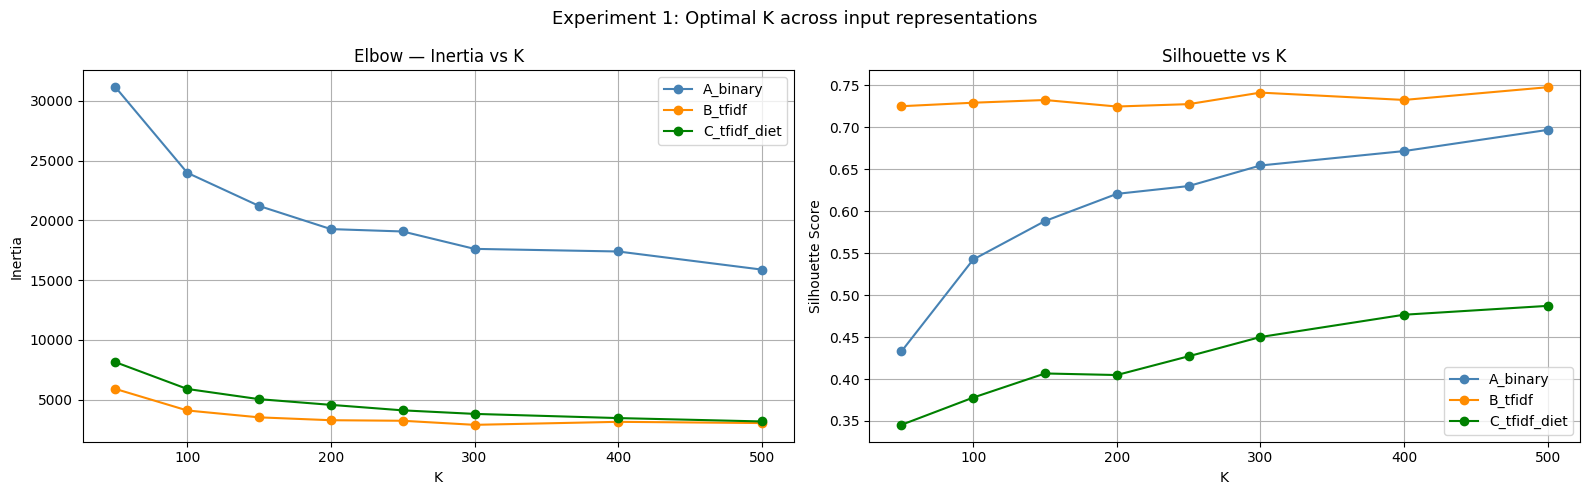


Matrix                 Best K   Best Silhouette
------------------------------------------------
A_binary                  500           0.6968
B_tfidf                   500           0.7476
C_tfidf_diet              500           0.4871


In [ ]:
colors = {"A_binary": "steelblue", "B_tfidf": "darkorange", "C_tfidf_diet": "green"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for name, data in results.items():
    ks   = [d["k"]         for d in data]
    ins  = [d["inertia"]   for d in data]
    sils = [d["silhouette"] for d in data]
    ax1.plot(ks, ins,  marker='o', label=name, color=colors[name])
    ax2.plot(ks, sils, marker='o', label=name, color=colors[name])

ax1.set_title("Elbow — Inertia vs K")
ax1.set_xlabel("K"); ax1.set_ylabel("Inertia")
ax1.legend(); ax1.grid(True)

ax2.set_title("Silhouette vs K")
ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette Score")
ax2.legend(); ax2.grid(True)

plt.suptitle("Experiment 1: Optimal K across input representations", fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Matrix':<20} {'Best K':>8} {'Best Silhouette':>17}")
print("-" * 48)
for name, data in results.items():
    best = max(data, key=lambda x: x["silhouette"])
    print(f"{name:<20} {best['k']:>8}  {best['silhouette']:>15.4f}")

── B_tfidf extended K sweep ──
  k=  500  silhouette=0.7476
  k=  600  silhouette=0.7154
  k=  700  silhouette=0.7246
  k=  800  silhouette=0.7426
  k=  900  silhouette=0.7550
  k= 1000  silhouette=0.7321
  k= 1200  silhouette=0.7403
  k= 1500  silhouette=0.7631


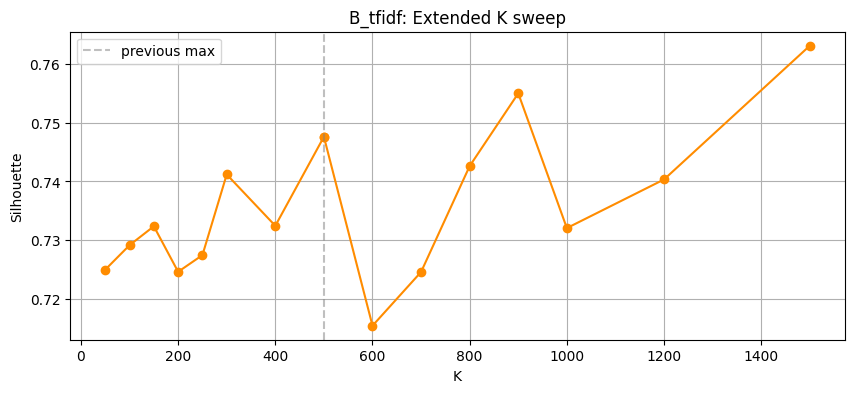


best K so far: 1500  silhouette=0.7631


In [ ]:
# Extend sweep — B_tfidf only, higher K values
k_values_extended = [500, 600, 700, 800, 900, 1000, 1200, 1500]
results_extended  = []

print("── B_tfidf extended K sweep ──")
for k in k_values_extended:
    km     = MiniBatchKMeans(n_clusters=k, random_state=42,
                             batch_size=4096, n_init=10, init='k-means++')
    labels = km.fit_predict(sB)
    sil    = silhouette_score(sB, labels, metric='euclidean',
                              sample_size=5000, random_state=42)
    results_extended.append({"k": k, "silhouette": sil})
    print(f"  k={k:>5}  silhouette={sil:.4f}")

plt.figure(figsize=(10, 4))
# Include original B results for continuity
all_k   = [d["k"] for d in results["B_tfidf"]] + [d["k"] for d in results_extended]
all_sil = [d["silhouette"] for d in results["B_tfidf"]] + [d["silhouette"] for d in results_extended]
plt.plot(all_k, all_sil, marker='o', color='darkorange')
plt.axvline(x=500, color='gray', linestyle='--', alpha=0.5, label='previous max')
plt.xlabel("K"); plt.ylabel("Silhouette")
plt.title("B_tfidf: Extended K sweep")
plt.legend(); plt.grid(True)
plt.show()

best_extended = max(results_extended, key=lambda x: x["silhouette"])
print(f"\nbest K so far: {best_extended['k']}  silhouette={best_extended['silhouette']:.4f}")

In [ ]:
# Stabilized sweep — higher n_init to reduce MiniBatch variance
# Covers the promising range and goes higher to find the true peak

k_candidates = [500, 750, 1000, 1500, 2000, 2500, 3000]
stable_results = []

print("── Stabilized sweep (n_init=25, batch_size=8192) ──")
for k in k_candidates:
    km     = MiniBatchKMeans(n_clusters=k, random_state=42,
                             batch_size=8192, n_init=25, init='k-means++')
    labels = km.fit_predict(sB)
    sil    = silhouette_score(sB, labels, metric='euclidean',
                              sample_size=5000, random_state=42)
    stable_results.append({"k": k, "silhouette": sil})
    print(f"  k={k:>5}  silhouette={sil:.4f}")

plt.figure(figsize=(10, 4))
plt.plot([r["k"] for r in stable_results],
         [r["silhouette"] for r in stable_results],
         marker='o', color='darkorange')
plt.xlabel("K"); plt.ylabel("Silhouette")
plt.title("B_tfidf: Stabilized sweep (n_init=25, batch=8192)")
plt.grid(True)
plt.show()

best_stable = max(stable_results, key=lambda x: x["silhouette"])
print(f"\nbest stable K: {best_stable['k']}  silhouette={best_stable['silhouette']:.4f}")

── Stabilized sweep (n_init=25, batch_size=8192) ──
  k=  500  silhouette=0.7598
  k=  750  silhouette=0.7202
  k= 1000  silhouette=0.7377
  k= 1500  silhouette=0.7780
  k= 2000  silhouette=0.7828
  k= 2500  silhouette=0.7755


KeyboardInterrupt: 

loading model...
  n_recipes:  2,231,142
  n_clusters: 100
  X shape:    (2231142, 179)

kept   1,649,782 recipes
dropped 581,360 zero-spice recipes

building TF-IDF matrix...
  X_B shape: (1649782, 179)

loading diet restrictions...
  1,312,871 unique recipes with diet labels

sample: 50,000 rows from 1,649,782 total

     K  Silhouette   Rec Quality   Filter Pres   Avg Cluster   Min Cluster     Inertia
----------------------------------------------------------------------------------
   100      0.7364        0.8600        0.4125       16497.8             0      3966.8  ⚠ small
   200      0.7369        0.8600        0.4125        8248.9             0      3388.3  ⚠ small
   300      0.7365        0.8600        0.4625        5499.3             0      3393.1  ⚠ small
   500      0.7598        0.8600        0.5250        3299.6             0      2801.8  ⚠ small
   750      0.7202        0.8600        0.4500        2199.7             0      2961.6  ⚠ small
  1000      0.7377        0.8

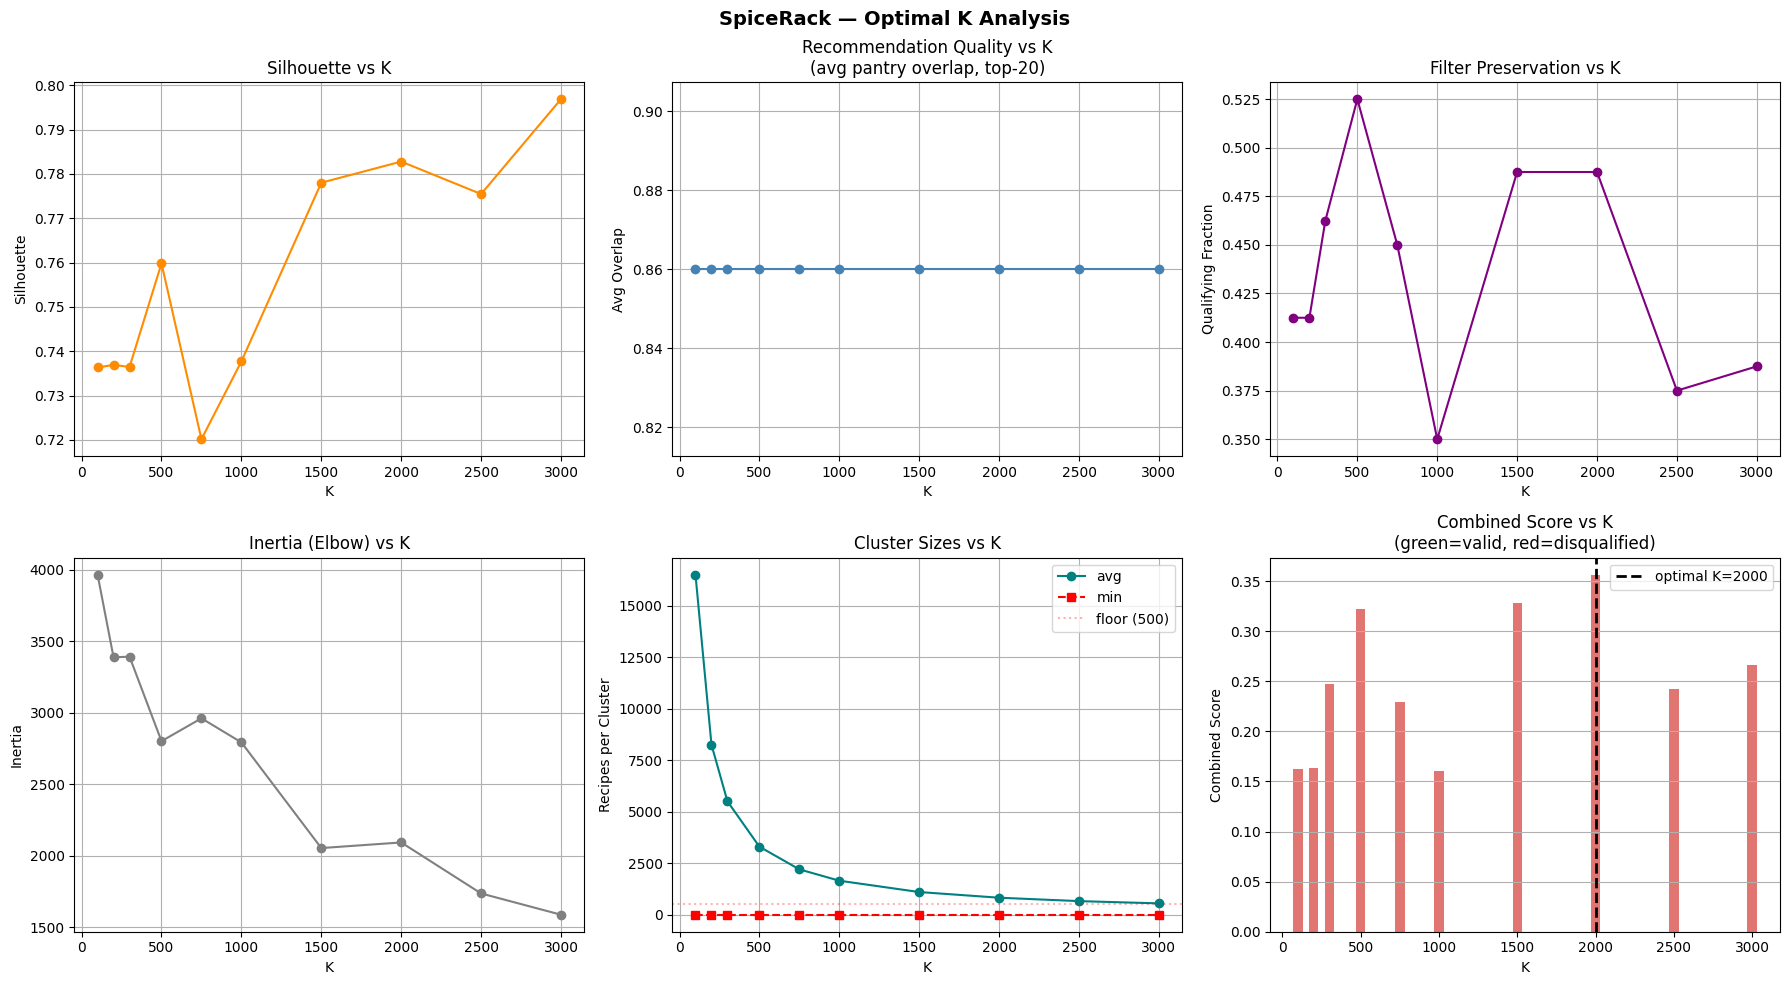

In [ ]:
# ============================================================
# SpiceRack — Optimal K Finder (Full Script)
# Criteria:
#   1. Silhouette (cluster geometric quality)
#   2. Recommendation quality (pantry overlap in top-20)
#   3. Filter preservation (diet filters still work post-hoc)
#   4. Inertia elbow (diminishing returns)
#   5. Minimum cluster size floor (practical cutoff)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster                 import MiniBatchKMeans
from sklearn.metrics                 import silhouette_score
from sklearn.preprocessing           import normalize
from sklearn.feature_extraction.text import TfidfTransformer
from scipy.sparse                    import csr_matrix
import joblib

from spice_data_v2 import SPICES, ALIASES, CANONICAL_SPICES


# ── CONFIG ────────────────────────────────────────────────────────────────────

MODEL_PATH   = "spicerack_model2.joblib"
RESTRICTIONS = "SpiceRack-website-main/data/full_recipes_with_restrictions.csv"

K_VALUES    = [100, 200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000]
N_INIT      = 25
BATCH_SIZE  = 8192
SIL_SAMPLE  = 5000
TOP_N       = 20
MIN_CLUSTER = 500

DIET_COLS = [
    'is_vegetarian', 'is_vegan', 'is_dairy_free', 'is_gluten_free',
    'is_keto', 'is_paleo', 'is_halal', 'is_kosher', 'is_hindu_friendly'
]

TEST_PANTRIES = [
    {"garlic", "cumin", "paprika", "salt", "black pepper"},
    {"cinnamon", "ginger", "nutmeg", "cloves", "cardamom"},
    {"ginger", "garlic", "soy sauce", "sesame oil"},
    {"oregano", "basil", "thyme", "garlic", "red pepper flakes"},
    {"turmeric", "cumin", "coriander", "garam masala", "chili powder"},
]

FILTERED_PANTRIES = [
    ({"garlic", "cumin", "paprika", "salt", "black pepper"}, "is_keto"),
    ({"oregano", "basil", "thyme", "garlic"},                "is_vegetarian"),
    ({"ginger", "turmeric", "cumin", "coriander"},           "is_vegan"),
    ({"cinnamon", "ginger", "cardamom", "cloves"},           "is_dairy_free"),
]

WEIGHTS = {"rec": 0.40, "sil": 0.25, "filter": 0.20, "elbow": 0.15}


# ── STEP 1: Load model ────────────────────────────────────────────────────────

print("loading model...")
m   = joblib.load(MODEL_PATH)
mlb = m["mlb"]
print(f"  n_recipes:  {m['n_recipes']:,}")
print(f"  n_clusters: {m['n_clusters']}")

X_raw = np.asarray(mlb.transform([set(s) for s in m["recipe_spices"]]))
print(f"  X shape:    {X_raw.shape}")


# ── STEP 2: Remove zero-spice recipes ─────────────────────────────────────────

nonempty_mask = X_raw.sum(axis=1) > 0
X_clean       = X_raw[nonempty_mask]
titles_clean  = [t for t, keep in zip(m["recipe_titles"], nonempty_mask) if keep]
recipe_spices_clean = [s for s, keep in zip(m["recipe_spices"], nonempty_mask) if keep]

print(f"\nkept   {X_clean.shape[0]:,} recipes")
print(f"dropped {(~nonempty_mask).sum():,} zero-spice recipes")
assert X_clean.shape[0] == len(titles_clean)
assert X_clean.shape[0] == len(recipe_spices_clean)


# ── STEP 3: Build TF-IDF + IDF² matrix ───────────────────────────────────────

print("\nbuilding TF-IDF matrix...")
X_sparse    = csr_matrix(X_clean.astype(np.float32))
tfidf       = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf     = tfidf.fit_transform(X_sparse)
idf_weights = np.array(tfidf.idf_)
idf_boost   = (idf_weights ** 2) / (idf_weights ** 2).max()
X_B         = normalize(X_tfidf.multiply(idf_boost), norm="l2")
print(f"  X_B shape: {X_B.shape}")


# ── STEP 4: Load diet lookup ──────────────────────────────────────────────────

print("\nloading diet restrictions...")
restrict_df = pd.read_csv(RESTRICTIONS)
restrict_df = restrict_df.drop_duplicates(subset='title', keep='first')
diet_lookup = restrict_df.set_index('title')[DIET_COLS].to_dict('index')
print(f"  {len(restrict_df):,} unique recipes with diet labels")


# ── STEP 5: Draw sample ───────────────────────────────────────────────────────

N_SAMPLE = 50_000
rng      = np.random.default_rng(42)
idx      = rng.choice(X_clean.shape[0], min(N_SAMPLE, X_clean.shape[0]), replace=False)
sB       = X_B[idx]
print(f"\nsample: {len(idx):,} rows from {X_clean.shape[0]:,} total")


# ── HELPERS ───────────────────────────────────────────────────────────────────

def build_user_vector(pantry: set):
    """pantry → TF-IDF + IDF² normalized sparse vector (1, n_spice_dims)"""
    user_bin   = np.asarray(mlb.transform([pantry]), dtype=np.float32)
    user_tfidf = tfidf.transform(csr_matrix(user_bin))
    return normalize(user_tfidf.multiply(idf_boost), norm="l2")


def recommendation_quality(km: MiniBatchKMeans,
                            labels_full: np.ndarray,
                            pantry: set) -> float:
    """
    Avg fractional pantry overlap in top-N recommendations.
    Uses labels_full (aligned to X_B rows) for cluster weighting.
    """
    user_vec    = build_user_vector(pantry)
    distances   = km.transform(user_vec)[0]          # (n_clusters,)
    sigma       = distances.mean()
    cluster_wts = np.exp(-(distances ** 2) / (2 * sigma ** 2))
    cluster_wts /= cluster_wts.max()                 # (n_clusters,)

    # cosine similarity against all recipes
    scores  = np.array(X_B.dot(user_vec.T).todense()).flatten()  # (n_full,)
    scores *= cluster_wts[labels_full]                            # (n_full,) ✓

    top_idx    = np.argsort(scores)[::-1][:TOP_N]
    pantry_len = max(len(pantry), 1)
    overlaps   = [
        len(pantry & set(recipe_spices_clean[i])) / pantry_len
        for i in top_idx
    ]
    return float(np.mean(overlaps))


def filter_preservation_quality(km: MiniBatchKMeans,
                                 labels_full: np.ndarray) -> float:
    """
    For each (pantry, diet_filter), fraction of top-N that satisfy the filter.
    Uses labels_full aligned to X_B rows.
    """
    scores = []
    for pantry, diet_col in FILTERED_PANTRIES:
        user_vec    = build_user_vector(pantry)
        distances   = km.transform(user_vec)[0]
        sigma       = distances.mean()
        cluster_wts = np.exp(-(distances ** 2) / (2 * sigma ** 2))
        cluster_wts /= cluster_wts.max()

        raw_scores  = np.array(X_B.dot(user_vec.T).todense()).flatten()  # (n_full,)
        raw_scores *= cluster_wts[labels_full]                            # (n_full,) ✓

        top_idx    = np.argsort(raw_scores)[::-1][:TOP_N]
        top_titles = [titles_clean[i] for i in top_idx]

        qualifying = sum(
            1 for t in top_titles
            if diet_lookup.get(t, {}).get(diet_col, False)
        )
        scores.append(qualifying / TOP_N)

    return float(np.mean(scores))


def inertia_elbow_scores(inertias: list) -> list:
    """Second derivative of inertia — peak = elbow."""
    arr = np.array(inertias, dtype=float)
    d1  = np.diff(arr)
    d2  = np.abs(np.diff(d1))
    return [0.0, 0.0] + d2.tolist()


def norm01(arr):
    mn, mx = min(arr), max(arr)
    if mx == mn:
        return [0.5] * len(arr)
    return [(x - mn) / (mx - mn) for x in arr]


# ── STEP 6: Main sweep ────────────────────────────────────────────────────────

all_results = []

print(f"\n{'K':>6}  {'Silhouette':>10}  {'Rec Quality':>12}  "
      f"{'Filter Pres':>12}  {'Avg Cluster':>12}  "
      f"{'Min Cluster':>12}  {'Inertia':>10}")
print("-" * 82)

for k in K_VALUES:
    # Fit on sample — fast and representative
    km = MiniBatchKMeans(
        n_clusters=k, random_state=42,
        batch_size=BATCH_SIZE, n_init=N_INIT, init='k-means++'
    )
    km.fit(sB)

    # Predict on FULL dataset — needed for scoring and cluster size stats
    labels_full   = km.predict(X_B)       # shape (n_full,) — aligned to X_B ✓
    labels_sample = km.predict(sB)        # shape (50000,)  — for silhouette

    # 1. Silhouette on sample
    sil = silhouette_score(
        sB, labels_sample,
        metric='euclidean',
        sample_size=SIL_SAMPLE,
        random_state=42
    )

    # 2. Inertia
    inertia = km.inertia_

    # 3. Cluster sizes from full dataset
    counts      = np.bincount(labels_full, minlength=k)
    avg_cluster = float(counts.mean())
    min_cluster = int(counts.min())

    # 4. Recommendation quality — pass labels_full explicitly
    rec_scores  = [recommendation_quality(km, labels_full, p) for p in TEST_PANTRIES]
    rec_quality = float(np.mean(rec_scores))

    # 5. Filter preservation — pass labels_full explicitly
    filter_pres = filter_preservation_quality(km, labels_full)

    flag = "  ⚠ small" if min_cluster < MIN_CLUSTER else ""
    print(f"{k:>6}  {sil:>10.4f}  {rec_quality:>12.4f}  "
          f"{filter_pres:>12.4f}  {avg_cluster:>12.1f}  "
          f"{min_cluster:>12}  {inertia:>10.1f}{flag}")

    all_results.append({
        "k":           k,
        "silhouette":  sil,
        "inertia":     inertia,
        "avg_cluster": avg_cluster,
        "min_cluster": min_cluster,
        "rec_quality": rec_quality,
        "filter_pres": filter_pres,
    })


# ── STEP 7: Combined scoring ───────────────────────────────────────────────────

elbow_raw   = inertia_elbow_scores([r["inertia"] for r in all_results])
sil_norm    = norm01([r["silhouette"]  for r in all_results])
rec_norm    = norm01([r["rec_quality"] for r in all_results])
filter_norm = norm01([r["filter_pres"] for r in all_results])
elbow_norm  = norm01(elbow_raw)

for i, r in enumerate(all_results):
    score = (
        WEIGHTS["rec"]    * rec_norm[i]    +
        WEIGHTS["sil"]    * sil_norm[i]    +
        WEIGHTS["filter"] * filter_norm[i] +
        WEIGHTS["elbow"]  * elbow_norm[i]
    )
    r["disqualified"]   = r["min_cluster"] < MIN_CLUSTER
    r["combined_score"] = score * 0.5 if r["disqualified"] else score
    r["elbow_score"]    = elbow_raw[i]


# ── STEP 8: Results table ─────────────────────────────────────────────────────

print(f"\n{'K':>6}  {'Silhouette':>10}  {'Rec':>8}  {'Filter':>8}  "
      f"{'Elbow':>8}  {'Combined':>10}  Note")
print("-" * 68)

for r in all_results:
    note = "⚠ disqualified" if r["disqualified"] else "✓"
    print(f"{r['k']:>6}  {r['silhouette']:>10.4f}  "
          f"{r['rec_quality']:>8.4f}  {r['filter_pres']:>8.4f}  "
          f"{r['elbow_score']:>8.1f}  {r['combined_score']:>10.4f}  {note}")

best = max(all_results, key=lambda x: x["combined_score"])

print(f"\n{'='*55}")
print(f"  OPTIMAL K         =  {best['k']}")
print(f"  Silhouette           {best['silhouette']:.4f}")
print(f"  Rec quality          {best['rec_quality']:.4f}")
print(f"  Filter preservation  {best['filter_pres']:.4f}")
print(f"  Avg cluster size     {best['avg_cluster']:.0f}")
print(f"  Min cluster size     {best['min_cluster']}")
print(f"  Combined score       {best['combined_score']:.4f}")
print(f"{'='*55}")
print(f"\n→ Set N_CLUSTERS = {best['k']} in spicerack_model_v3")


# ── STEP 9: Plots ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ks       = [r["k"]             for r in all_results]
sils     = [r["silhouette"]    for r in all_results]
recs     = [r["rec_quality"]   for r in all_results]
filts    = [r["filter_pres"]   for r in all_results]
inerts   = [r["inertia"]       for r in all_results]
combined = [r["combined_score"]for r in all_results]
disq     = [r["disqualified"]  for r in all_results]
avgs     = [r["avg_cluster"]   for r in all_results]
mins     = [r["min_cluster"]   for r in all_results]

# 1 — Silhouette
axes[0,0].plot(ks, sils, marker='o', color='darkorange')
axes[0,0].set_title("Silhouette vs K")
axes[0,0].set_xlabel("K"); axes[0,0].set_ylabel("Silhouette")
axes[0,0].grid(True)

# 2 — Rec quality
axes[0,1].plot(ks, recs, marker='o', color='steelblue')
axes[0,1].set_title("Recommendation Quality vs K\n(avg pantry overlap, top-20)")
axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("Avg Overlap")
axes[0,1].grid(True)

# 3 — Filter preservation
axes[0,2].plot(ks, filts, marker='o', color='purple')
axes[0,2].set_title("Filter Preservation vs K")
axes[0,2].set_xlabel("K"); axes[0,2].set_ylabel("Qualifying Fraction")
axes[0,2].grid(True)

# 4 — Inertia elbow
axes[1,0].plot(ks, inerts, marker='o', color='gray')
axes[1,0].set_title("Inertia (Elbow) vs K")
axes[1,0].set_xlabel("K"); axes[1,0].set_ylabel("Inertia")
axes[1,0].grid(True)

# 5 — Cluster sizes
axes[1,1].plot(ks, avgs, marker='o', color='teal',  label='avg')
axes[1,1].plot(ks, mins, marker='s', color='red',   label='min', linestyle='--')
axes[1,1].axhline(y=MIN_CLUSTER, color='red', alpha=0.3,
                  linestyle=':', label=f'floor ({MIN_CLUSTER})')
axes[1,1].set_title("Cluster Sizes vs K")
axes[1,1].set_xlabel("K"); axes[1,1].set_ylabel("Recipes per Cluster")
axes[1,1].legend(); axes[1,1].grid(True)

# 6 — Combined score
bar_colors = ['#d9534f' if d else '#5cb85c' for d in disq]
axes[1,2].bar(ks, combined, color=bar_colors, alpha=0.8, width=60)
axes[1,2].axvline(x=best["k"], color='black', linestyle='--',
                  linewidth=2, label=f"optimal K={best['k']}")
axes[1,2].set_title("Combined Score vs K\n(green=valid, red=disqualified)")
axes[1,2].set_xlabel("K"); axes[1,2].set_ylabel("Combined Score")
axes[1,2].legend(); axes[1,2].grid(True, axis='y')

plt.suptitle("SpiceRack — Optimal K Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

checking paths...
  ✓  spicerack_model2.joblib  (1021.6 MB)
  ✓  SpiceRack-website-main/data/full_recipes_with_restrictions.csv  (2734.8 MB)

loading model...
  n_recipes:  2,231,142
  n_clusters: 100
  X shape:    (2231142, 179)

kept    1,649,782 recipes
dropped 581,360 zero-spice recipes
shape checks passed

building TF-IDF matrix...
  X_B shape: (1649782, 179)

loading diet restrictions...
  1,312,871 unique recipes with diet labels

silhouette sample: 50,000 rows
precomputing filter pantry scores...
  precomputed 4 filter pantry score vectors

     K  Silhouette    Coherence   Filter Pres   Avg Cluster     Inertia
------------------------------------------------------------------------
   300      0.7452       0.9190        0.4375        5499.3     98488.8
   500      0.7363       0.9246        0.4750        3299.6     99316.2
   750      0.7174       0.9270        0.3750        2199.7     93402.3
  1000      0.7569       0.9029        0.4500        1649.8     87215.8
  1500      

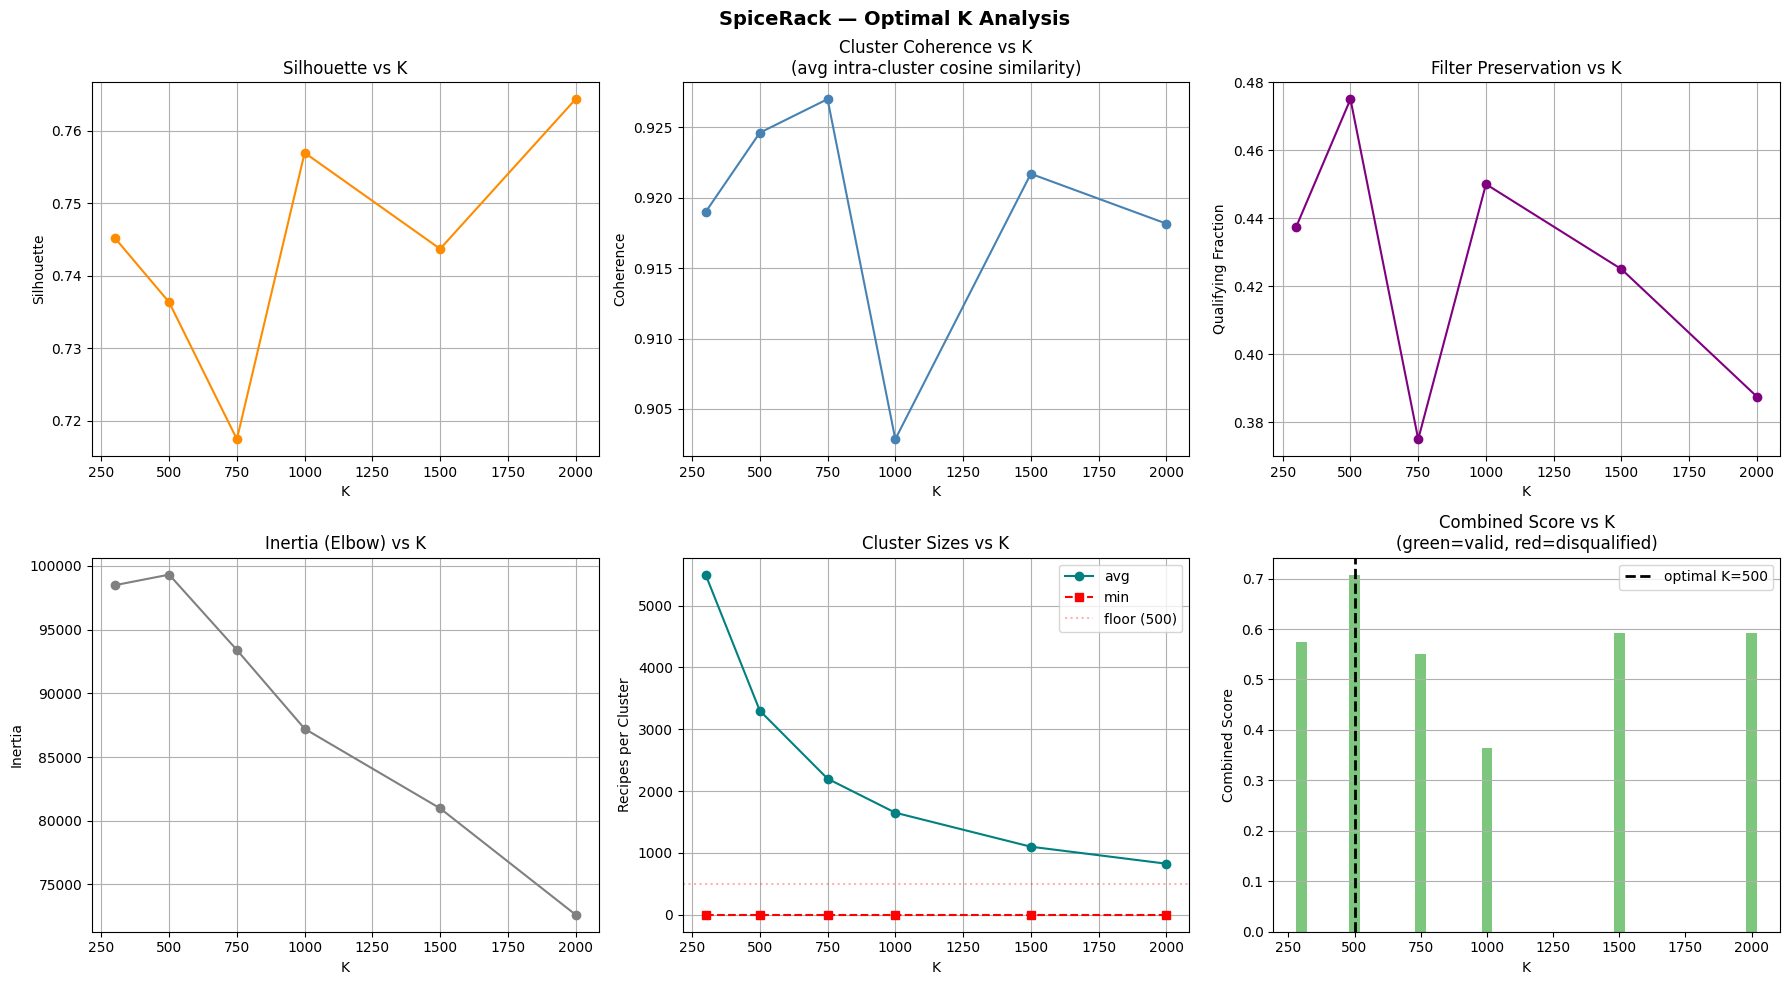

In [ ]:
# ============================================================
# SpiceRack — Optimal K Finder (Final Script)
# Criteria:
#   1. Silhouette (cluster geometric quality)
#   2. Cluster coherence (intra-cluster recipe similarity — replaces flat rec quality)
#   3. Filter preservation (diet filters still work post-hoc)
#   4. Inertia elbow (diminishing returns)
#   5. Average cluster size floor (practical cutoff)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster                 import MiniBatchKMeans
from sklearn.metrics                 import silhouette_score
from sklearn.preprocessing           import normalize
from sklearn.feature_extraction.text import TfidfTransformer
from scipy.sparse                    import csr_matrix
import joblib
import os

from spice_data_v2 import SPICES, ALIASES, CANONICAL_SPICES


# ── CONFIG ────────────────────────────────────────────────────────────────────

MODEL_PATH   = "spicerack_model2.joblib"
RESTRICTIONS = "SpiceRack-website-main/data/full_recipes_with_restrictions.csv"

K_VALUES    = [300, 500, 750, 1000, 1500, 2000]

N_INIT      = 25
BATCH_SIZE  = 8192
SIL_SAMPLE  = 5000
TOP_N       = 20
MIN_CLUSTER = 500

DIET_COLS = [
    'is_vegetarian', 'is_vegan', 'is_dairy_free', 'is_gluten_free',
    'is_keto', 'is_paleo', 'is_halal', 'is_kosher', 'is_hindu_friendly'
]

FILTERED_PANTRIES = [
    ({"garlic", "cumin", "paprika", "salt", "black pepper"}, "is_keto"),
    ({"oregano", "basil", "thyme", "garlic"},                "is_vegetarian"),
    ({"ginger", "turmeric", "cumin", "coriander"},           "is_vegan"),
    ({"cinnamon", "ginger", "cardamom", "cloves"},           "is_dairy_free"),
]

# Coherence weighted highest — it's the only metric that truly varies with K
WEIGHTS = {"coherence": 0.45, "sil": 0.25, "filter": 0.20, "elbow": 0.10}


# ── STEP 0: Path check ────────────────────────────────────────────────────────

print("checking paths...")
for p in [MODEL_PATH, RESTRICTIONS]:
    exists = os.path.exists(p)
    size   = f"{os.path.getsize(p)/1e6:.1f} MB" if exists else "NOT FOUND"
    print(f"  {'✓' if exists else '✗'}  {p}  ({size})")


# ── STEP 1: Load model ────────────────────────────────────────────────────────

print("\nloading model...")
m   = joblib.load(MODEL_PATH)
mlb = m["mlb"]
print(f"  n_recipes:  {m['n_recipes']:,}")
print(f"  n_clusters: {m['n_clusters']}")

X_raw = np.asarray(mlb.transform([set(s) for s in m["recipe_spices"]]))
print(f"  X shape:    {X_raw.shape}")


# ── STEP 2: Remove zero-spice recipes ─────────────────────────────────────────

nonempty_mask       = X_raw.sum(axis=1) > 0
X_clean             = X_raw[nonempty_mask]
titles_clean        = [t for t, k in zip(m["recipe_titles"], nonempty_mask) if k]
recipe_spices_clean = [s for s, k in zip(m["recipe_spices"], nonempty_mask) if k]

print(f"\nkept    {X_clean.shape[0]:,} recipes")
print(f"dropped {(~nonempty_mask).sum():,} zero-spice recipes")
assert X_clean.shape[0] == len(titles_clean)
assert X_clean.shape[0] == len(recipe_spices_clean)
print("shape checks passed")


# ── STEP 3: Build TF-IDF + IDF² matrix ───────────────────────────────────────

print("\nbuilding TF-IDF matrix...")
X_sparse    = csr_matrix(X_clean.astype(np.float32))
tfidf       = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf     = tfidf.fit_transform(X_sparse)
idf_weights = np.array(tfidf.idf_)
idf_boost   = (idf_weights ** 2) / (idf_weights ** 2).max()
X_B         = normalize(X_tfidf.multiply(idf_boost), norm="l2")
print(f"  X_B shape: {X_B.shape}")


# ── STEP 4: Load diet lookup ──────────────────────────────────────────────────

print("\nloading diet restrictions...")
restrict_df = pd.read_csv(RESTRICTIONS)
restrict_df = restrict_df.drop_duplicates(subset='title', keep='first')
diet_lookup = restrict_df.set_index('title')[DIET_COLS].to_dict('index')
print(f"  {len(restrict_df):,} unique recipes with diet labels")


# ── STEP 5: Sample + precompute filter scores ─────────────────────────────────
# Filter scores are precomputed once — only cluster weighting changes per K

N_SAMPLE = 50_000
rng      = np.random.default_rng(42)
idx      = rng.choice(X_clean.shape[0], min(N_SAMPLE, X_clean.shape[0]), replace=False)
sB       = X_B[idx]
print(f"\nsilhouette sample: {len(idx):,} rows")

print("precomputing filter pantry scores...")
filter_scores_raw = {}
filter_user_vecs  = {}

for pantry, diet_col in FILTERED_PANTRIES:
    key        = frozenset(pantry)
    user_bin   = np.asarray(mlb.transform([pantry]), dtype=np.float32)
    user_tfidf = tfidf.transform(csr_matrix(user_bin))
    user_vec   = normalize(user_tfidf.multiply(idf_boost), norm="l2")
    raw        = np.array(X_B.dot(user_vec.T).todense()).flatten()
    filter_scores_raw[key] = raw
    filter_user_vecs[key]  = user_vec

print(f"  precomputed {len(filter_scores_raw)} filter pantry score vectors")


# ── HELPERS ───────────────────────────────────────────────────────────────────

def cluster_coherence(labels_full: np.ndarray,
                      sample_per_cluster: int = 30,
                      max_clusters: int = 100) -> float:
    """
    Avg intra-cluster cosine similarity across a sample of clusters.
    Higher = tighter clusters = better flavor grouping.
    This metric varies meaningfully with K — unlike raw pantry overlap.

    sample_per_cluster: how many recipes to sample per cluster
    max_clusters: cap to keep runtime manageable
    """
    rng2           = np.random.default_rng(99)
    unique_clusters = np.unique(labels_full)
    # Sample a random subset of clusters to evaluate
    eval_clusters  = rng2.choice(
        unique_clusters,
        min(max_clusters, len(unique_clusters)),
        replace=False
    )

    similarities = []
    for cid in eval_clusters:
        cluster_idx = np.where(labels_full == cid)[0]
        if len(cluster_idx) < 2:
            continue
        # Sample up to sample_per_cluster recipes from this cluster
        sample_idx   = rng2.choice(
            cluster_idx,
            min(sample_per_cluster, len(cluster_idx)),
            replace=False
        )
        vecs = X_B[sample_idx]          # sparse (n_sample, n_dims)
        dot  = (vecs @ vecs.T).toarray()
        n    = dot.shape[0]
        # Upper triangle only — excludes self-similarity
        upper = dot[np.triu_indices(n, k=1)]
        if len(upper) > 0:
            similarities.append(float(upper.mean()))

    return float(np.mean(similarities)) if similarities else 0.0


def filter_preservation_quality(km, labels_full: np.ndarray) -> float:
    """
    Fraction of top-N satisfying each diet filter.
    Uses precomputed raw scores — only cluster weighting depends on K.
    """
    scores = []
    for pantry, diet_col in FILTERED_PANTRIES:
        key         = frozenset(pantry)
        raw         = filter_scores_raw[key]
        user_vec    = filter_user_vecs[key]

        distances   = km.transform(user_vec)[0]
        sigma       = max(distances.mean(), 1e-9)
        cluster_wts = np.exp(-(distances ** 2) / (2 * sigma ** 2))
        cluster_wts /= cluster_wts.max()

        weighted   = raw * cluster_wts[labels_full]
        top_idx    = np.argsort(weighted)[::-1][:TOP_N]
        top_titles = [titles_clean[i] for i in top_idx]

        qualifying = sum(
            1 for t in top_titles
            if diet_lookup.get(t, {}).get(diet_col, False)
        )
        scores.append(qualifying / TOP_N)

    return float(np.mean(scores))


def inertia_elbow_scores(inertias: list) -> list:
    arr = np.array(inertias, dtype=float)
    d1  = np.diff(arr)
    d2  = np.abs(np.diff(d1))
    return [0.0, 0.0] + d2.tolist()


def norm01(arr):
    mn, mx = min(arr), max(arr)
    if mx == mn:
        return [0.5] * len(arr)
    return [(x - mn) / (mx - mn) for x in arr]


# ── STEP 6: Main sweep ────────────────────────────────────────────────────────

all_results = []

print(f"\n{'K':>6}  {'Silhouette':>10}  {'Coherence':>11}  "
      f"{'Filter Pres':>12}  {'Avg Cluster':>12}  {'Inertia':>10}")
print("-" * 72)

for k in K_VALUES:
    print(f"  fitting K={k}...", end="", flush=True)

    km = MiniBatchKMeans(
        n_clusters=k, random_state=42,
        batch_size=BATCH_SIZE, n_init=N_INIT, init='k-means++'
    )
    km.fit(X_B)

    labels_full   = km.labels_
    labels_sample = km.predict(sB)

    # 1. Silhouette on sample
    sil = silhouette_score(
        sB, labels_sample,
        metric='euclidean',
        sample_size=SIL_SAMPLE,
        random_state=42
    )

    # 2. Inertia
    inertia = km.inertia_

    # 3. Cluster sizes
    counts      = np.bincount(labels_full, minlength=k)
    avg_cluster = float(counts.mean())
    min_cluster = int(counts.min())
    too_small   = avg_cluster < MIN_CLUSTER

    # 4. Cluster coherence — varies with K, measures flavor group tightness
    coherence = cluster_coherence(labels_full)

    # 5. Filter preservation — uses precomputed scores, fast
    filter_pres = filter_preservation_quality(km, labels_full)

    flag = "  ⚠ avg too small" if too_small else ""
    print(f"\r{k:>6}  {sil:>10.4f}  {coherence:>11.4f}  "
          f"{filter_pres:>12.4f}  {avg_cluster:>12.1f}  "
          f"{inertia:>10.1f}{flag}")

    all_results.append({
        "k":           k,
        "silhouette":  sil,
        "coherence":   coherence,
        "inertia":     inertia,
        "avg_cluster": avg_cluster,
        "min_cluster": min_cluster,
        "filter_pres": filter_pres,
        "too_small":   too_small,
    })


# ── STEP 7: Combined scoring ───────────────────────────────────────────────────

elbow_raw      = inertia_elbow_scores([r["inertia"]   for r in all_results])
sil_norm       = norm01([r["silhouette"]  for r in all_results])
coherence_norm = norm01([r["coherence"]   for r in all_results])
filter_norm    = norm01([r["filter_pres"] for r in all_results])
elbow_norm     = norm01(elbow_raw)

for i, r in enumerate(all_results):
    score = (
        WEIGHTS["coherence"] * coherence_norm[i] +
        WEIGHTS["sil"]       * sil_norm[i]       +
        WEIGHTS["filter"]    * filter_norm[i]     +
        WEIGHTS["elbow"]     * elbow_norm[i]
    )
    r["disqualified"]   = r["too_small"]
    r["combined_score"] = score * 0.5 if r["disqualified"] else score
    r["elbow_score"]    = elbow_raw[i]


# ── STEP 8: Results table ─────────────────────────────────────────────────────

print(f"\n{'K':>6}  {'Silhouette':>10}  {'Coherence':>11}  {'Filter':>8}  "
      f"{'Elbow':>8}  {'Combined':>10}  Note")
print("-" * 70)

for r in all_results:
    note = "⚠ disqualified" if r["disqualified"] else "✓"
    print(f"{r['k']:>6}  {r['silhouette']:>10.4f}  "
          f"{r['coherence']:>11.4f}  {r['filter_pres']:>8.4f}  "
          f"{r['elbow_score']:>8.1f}  {r['combined_score']:>10.4f}  {note}")

best = max(all_results, key=lambda x: x["combined_score"])

print(f"\n{'='*55}")
print(f"  OPTIMAL K         =  {best['k']}")
print(f"  Silhouette           {best['silhouette']:.4f}")
print(f"  Coherence            {best['coherence']:.4f}")
print(f"  Filter preservation  {best['filter_pres']:.4f}")
print(f"  Avg cluster size     {best['avg_cluster']:.0f}")
print(f"  Min cluster size     {best['min_cluster']}")
print(f"  Combined score       {best['combined_score']:.4f}")
print(f"{'='*55}")
print(f"\n→ Set N_CLUSTERS = {best['k']} in spicerack_model_v3")


# ── STEP 9: Plots ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ks        = [r["k"]             for r in all_results]
sils      = [r["silhouette"]    for r in all_results]
coherences= [r["coherence"]     for r in all_results]
filts     = [r["filter_pres"]   for r in all_results]
inerts    = [r["inertia"]       for r in all_results]
combined  = [r["combined_score"]for r in all_results]
disq      = [r["disqualified"]  for r in all_results]
avgs      = [r["avg_cluster"]   for r in all_results]
mins      = [r["min_cluster"]   for r in all_results]

axes[0,0].plot(ks, sils, marker='o', color='darkorange')
axes[0,0].set_title("Silhouette vs K")
axes[0,0].set_xlabel("K"); axes[0,0].set_ylabel("Silhouette")
axes[0,0].grid(True)

axes[0,1].plot(ks, coherences, marker='o', color='steelblue')
axes[0,1].set_title("Cluster Coherence vs K\n(avg intra-cluster cosine similarity)")
axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("Coherence")
axes[0,1].grid(True)

axes[0,2].plot(ks, filts, marker='o', color='purple')
axes[0,2].set_title("Filter Preservation vs K")
axes[0,2].set_xlabel("K"); axes[0,2].set_ylabel("Qualifying Fraction")
axes[0,2].grid(True)

axes[1,0].plot(ks, inerts, marker='o', color='gray')
axes[1,0].set_title("Inertia (Elbow) vs K")
axes[1,0].set_xlabel("K"); axes[1,0].set_ylabel("Inertia")
axes[1,0].grid(True)

axes[1,1].plot(ks, avgs, marker='o', color='teal',  label='avg')
axes[1,1].plot(ks, mins, marker='s', color='red',   label='min', linestyle='--')
axes[1,1].axhline(y=MIN_CLUSTER, color='red', alpha=0.3,
                  linestyle=':', label=f'floor ({MIN_CLUSTER})')
axes[1,1].set_title("Cluster Sizes vs K")
axes[1,1].set_xlabel("K"); axes[1,1].set_ylabel("Recipes per Cluster")
axes[1,1].legend(); axes[1,1].grid(True)

bar_colors = ['#d9534f' if d else '#5cb85c' for d in disq]
axes[1,2].bar(ks, combined, color=bar_colors, alpha=0.8, width=40)
axes[1,2].axvline(x=best["k"], color='black', linestyle='--',
                  linewidth=2, label=f"optimal K={best['k']}")
axes[1,2].set_title("Combined Score vs K\n(green=valid, red=disqualified)")
axes[1,2].set_xlabel("K"); axes[1,2].set_ylabel("Combined Score")
axes[1,2].legend(); axes[1,2].grid(True, axis='y')

plt.suptitle("SpiceRack — Optimal K Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

checking paths...
  ✓  spicerack_model2.joblib  (1021.6 MB)
  ✓  SpiceRack-website-main/data/full_recipes_with_restrictions.csv  (2734.8 MB)

loading model...
  n_recipes:  2,231,142
  n_clusters: 100
  X shape:    (2231142, 179)

kept    1,649,782 recipes
dropped 581,360 zero-spice recipes
shape checks passed

building TF-IDF matrix...
  X_B shape: (1649782, 179)

loading diet restrictions...
  1,312,871 unique recipes with diet labels

silhouette sample: 50,000 rows
precomputing filter pantry scores...
  precomputed 4 filter pantry score vectors

     K  Silhouette    Coherence   Filter Pres   Avg Cluster     Inertia
------------------------------------------------------------------------
   400      0.7238       0.9314        0.5500        4124.5    102744.2
   450      0.7606       0.9294        0.4125        3666.2     90948.1
   500      0.7363       0.9246        0.4750        3299.6     99316.2
   550      0.7509       0.9307        0.4000        2999.6     98969.8
   600      

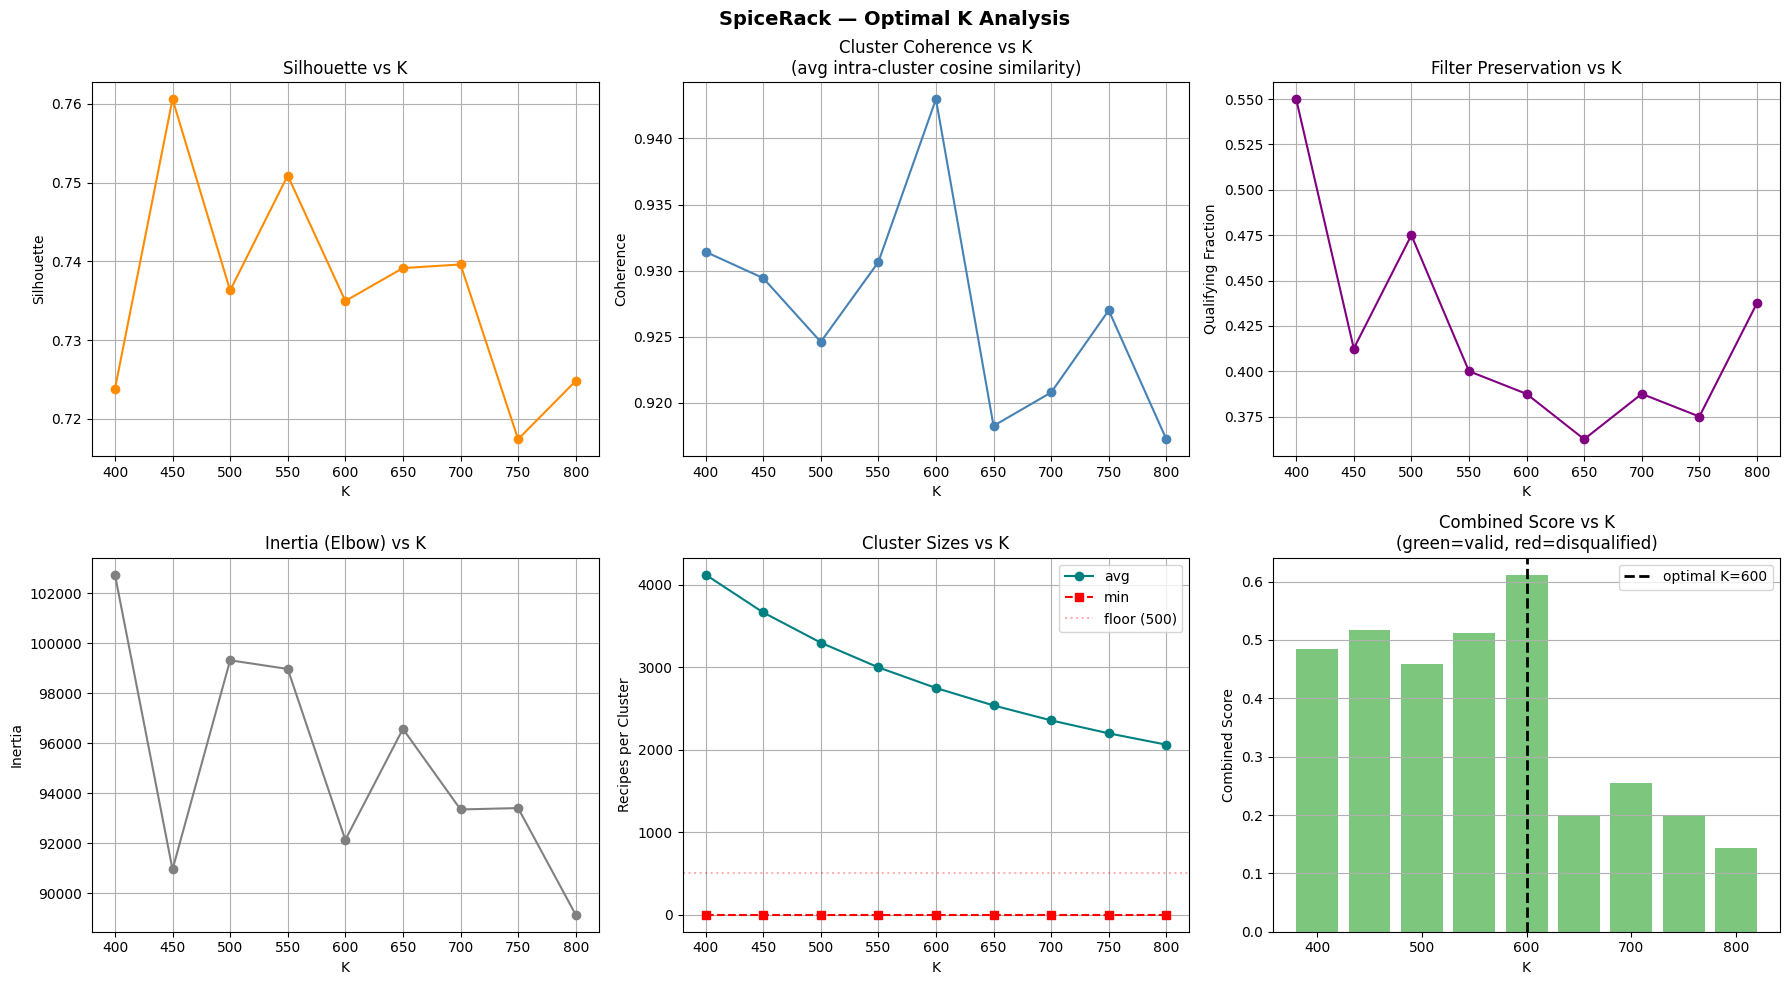

In [ ]:
# Refined tuning of previous script on more precise clusters 

# ── CONFIG ────────────────────────────────────────────────────────────────────

MODEL_PATH   = "spicerack_model2.joblib"
RESTRICTIONS = "SpiceRack-website-main/data/full_recipes_with_restrictions.csv"

K_VALUES = [400, 450, 500, 550, 600, 650, 700, 750, 800]

N_INIT      = 25
BATCH_SIZE  = 8192
SIL_SAMPLE  = 5000
TOP_N       = 20
MIN_CLUSTER = 500

DIET_COLS = [
    'is_vegetarian', 'is_vegan', 'is_dairy_free', 'is_gluten_free',
    'is_keto', 'is_paleo', 'is_halal', 'is_kosher', 'is_hindu_friendly'
]

FILTERED_PANTRIES = [
    ({"garlic", "cumin", "paprika", "salt", "black pepper"}, "is_keto"),
    ({"oregano", "basil", "thyme", "garlic"},                "is_vegetarian"),
    ({"ginger", "turmeric", "cumin", "coriander"},           "is_vegan"),
    ({"cinnamon", "ginger", "cardamom", "cloves"},           "is_dairy_free"),
]

# Coherence weighted highest — it's the only metric that truly varies with K
WEIGHTS = {"coherence": 0.45, "sil": 0.25, "filter": 0.20, "elbow": 0.10}


# ── STEP 0: Path check ────────────────────────────────────────────────────────

print("checking paths...")
for p in [MODEL_PATH, RESTRICTIONS]:
    exists = os.path.exists(p)
    size   = f"{os.path.getsize(p)/1e6:.1f} MB" if exists else "NOT FOUND"
    print(f"  {'✓' if exists else '✗'}  {p}  ({size})")


# ── STEP 1: Load model ────────────────────────────────────────────────────────

print("\nloading model...")
m   = joblib.load(MODEL_PATH)
mlb = m["mlb"]
print(f"  n_recipes:  {m['n_recipes']:,}")
print(f"  n_clusters: {m['n_clusters']}")

X_raw = np.asarray(mlb.transform([set(s) for s in m["recipe_spices"]]))
print(f"  X shape:    {X_raw.shape}")


# ── STEP 2: Remove zero-spice recipes ─────────────────────────────────────────

nonempty_mask       = X_raw.sum(axis=1) > 0
X_clean             = X_raw[nonempty_mask]
titles_clean        = [t for t, k in zip(m["recipe_titles"], nonempty_mask) if k]
recipe_spices_clean = [s for s, k in zip(m["recipe_spices"], nonempty_mask) if k]

print(f"\nkept    {X_clean.shape[0]:,} recipes")
print(f"dropped {(~nonempty_mask).sum():,} zero-spice recipes")
assert X_clean.shape[0] == len(titles_clean)
assert X_clean.shape[0] == len(recipe_spices_clean)
print("shape checks passed")


# ── STEP 3: Build TF-IDF + IDF² matrix ───────────────────────────────────────

print("\nbuilding TF-IDF matrix...")
X_sparse    = csr_matrix(X_clean.astype(np.float32))
tfidf       = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf     = tfidf.fit_transform(X_sparse)
idf_weights = np.array(tfidf.idf_)
idf_boost   = (idf_weights ** 2) / (idf_weights ** 2).max()
X_B         = normalize(X_tfidf.multiply(idf_boost), norm="l2")
print(f"  X_B shape: {X_B.shape}")


# ── STEP 4: Load diet lookup ──────────────────────────────────────────────────

print("\nloading diet restrictions...")
restrict_df = pd.read_csv(RESTRICTIONS)
restrict_df = restrict_df.drop_duplicates(subset='title', keep='first')
diet_lookup = restrict_df.set_index('title')[DIET_COLS].to_dict('index')
print(f"  {len(restrict_df):,} unique recipes with diet labels")


# ── STEP 5: Sample + precompute filter scores ─────────────────────────────────
# Filter scores are precomputed once — only cluster weighting changes per K

N_SAMPLE = 50_000
rng      = np.random.default_rng(42)
idx      = rng.choice(X_clean.shape[0], min(N_SAMPLE, X_clean.shape[0]), replace=False)
sB       = X_B[idx]
print(f"\nsilhouette sample: {len(idx):,} rows")

print("precomputing filter pantry scores...")
filter_scores_raw = {}
filter_user_vecs  = {}

for pantry, diet_col in FILTERED_PANTRIES:
    key        = frozenset(pantry)
    user_bin   = np.asarray(mlb.transform([pantry]), dtype=np.float32)
    user_tfidf = tfidf.transform(csr_matrix(user_bin))
    user_vec   = normalize(user_tfidf.multiply(idf_boost), norm="l2")
    raw        = np.array(X_B.dot(user_vec.T).todense()).flatten()
    filter_scores_raw[key] = raw
    filter_user_vecs[key]  = user_vec

print(f"  precomputed {len(filter_scores_raw)} filter pantry score vectors")


# ── HELPERS ───────────────────────────────────────────────────────────────────

def cluster_coherence(labels_full: np.ndarray,
                      sample_per_cluster: int = 30,
                      max_clusters: int = 100) -> float:
    """
    Avg intra-cluster cosine similarity across a sample of clusters.
    Higher = tighter clusters = better flavor grouping.
    This metric varies meaningfully with K — unlike raw pantry overlap.

    sample_per_cluster: how many recipes to sample per cluster
    max_clusters: cap to keep runtime manageable
    """
    rng2           = np.random.default_rng(99)
    unique_clusters = np.unique(labels_full)
    # Sample a random subset of clusters to evaluate
    eval_clusters  = rng2.choice(
        unique_clusters,
        min(max_clusters, len(unique_clusters)),
        replace=False
    )

    similarities = []
    for cid in eval_clusters:
        cluster_idx = np.where(labels_full == cid)[0]
        if len(cluster_idx) < 2:
            continue
        # Sample up to sample_per_cluster recipes from this cluster
        sample_idx   = rng2.choice(
            cluster_idx,
            min(sample_per_cluster, len(cluster_idx)),
            replace=False
        )
        vecs = X_B[sample_idx]          # sparse (n_sample, n_dims)
        dot  = (vecs @ vecs.T).toarray()
        n    = dot.shape[0]
        # Upper triangle only — excludes self-similarity
        upper = dot[np.triu_indices(n, k=1)]
        if len(upper) > 0:
            similarities.append(float(upper.mean()))

    return float(np.mean(similarities)) if similarities else 0.0


def filter_preservation_quality(km, labels_full: np.ndarray) -> float:
    """
    Fraction of top-N satisfying each diet filter.
    Uses precomputed raw scores — only cluster weighting depends on K.
    """
    scores = []
    for pantry, diet_col in FILTERED_PANTRIES:
        key         = frozenset(pantry)
        raw         = filter_scores_raw[key]
        user_vec    = filter_user_vecs[key]

        distances   = km.transform(user_vec)[0]
        sigma       = max(distances.mean(), 1e-9)
        cluster_wts = np.exp(-(distances ** 2) / (2 * sigma ** 2))
        cluster_wts /= cluster_wts.max()

        weighted   = raw * cluster_wts[labels_full]
        top_idx    = np.argsort(weighted)[::-1][:TOP_N]
        top_titles = [titles_clean[i] for i in top_idx]

        qualifying = sum(
            1 for t in top_titles
            if diet_lookup.get(t, {}).get(diet_col, False)
        )
        scores.append(qualifying / TOP_N)

    return float(np.mean(scores))


def inertia_elbow_scores(inertias: list) -> list:
    arr = np.array(inertias, dtype=float)
    d1  = np.diff(arr)
    d2  = np.abs(np.diff(d1))
    return [0.0, 0.0] + d2.tolist()


def norm01(arr):
    mn, mx = min(arr), max(arr)
    if mx == mn:
        return [0.5] * len(arr)
    return [(x - mn) / (mx - mn) for x in arr]


# ── STEP 6: Main sweep ────────────────────────────────────────────────────────

all_results = []

print(f"\n{'K':>6}  {'Silhouette':>10}  {'Coherence':>11}  "
      f"{'Filter Pres':>12}  {'Avg Cluster':>12}  {'Inertia':>10}")
print("-" * 72)

for k in K_VALUES:
    print(f"  fitting K={k}...", end="", flush=True)

    km = MiniBatchKMeans(
        n_clusters=k, random_state=42,
        batch_size=BATCH_SIZE, n_init=N_INIT, init='k-means++'
    )
    km.fit(X_B)

    labels_full   = km.labels_
    labels_sample = km.predict(sB)

    # 1. Silhouette on sample
    sil = silhouette_score(
        sB, labels_sample,
        metric='euclidean',
        sample_size=SIL_SAMPLE,
        random_state=42
    )

    # 2. Inertia
    inertia = km.inertia_

    # 3. Cluster sizes
    counts      = np.bincount(labels_full, minlength=k)
    avg_cluster = float(counts.mean())
    min_cluster = int(counts.min())
    too_small   = avg_cluster < MIN_CLUSTER

    # 4. Cluster coherence — varies with K, measures flavor group tightness
    coherence = cluster_coherence(labels_full)

    # 5. Filter preservation — uses precomputed scores, fast
    filter_pres = filter_preservation_quality(km, labels_full)

    flag = "  ⚠ avg too small" if too_small else ""
    print(f"\r{k:>6}  {sil:>10.4f}  {coherence:>11.4f}  "
          f"{filter_pres:>12.4f}  {avg_cluster:>12.1f}  "
          f"{inertia:>10.1f}{flag}")

    all_results.append({
        "k":           k,
        "silhouette":  sil,
        "coherence":   coherence,
        "inertia":     inertia,
        "avg_cluster": avg_cluster,
        "min_cluster": min_cluster,
        "filter_pres": filter_pres,
        "too_small":   too_small,
    })


# ── STEP 7: Combined scoring ───────────────────────────────────────────────────

elbow_raw      = inertia_elbow_scores([r["inertia"]   for r in all_results])
sil_norm       = norm01([r["silhouette"]  for r in all_results])
coherence_norm = norm01([r["coherence"]   for r in all_results])
filter_norm    = norm01([r["filter_pres"] for r in all_results])
elbow_norm     = norm01(elbow_raw)

for i, r in enumerate(all_results):
    score = (
        WEIGHTS["coherence"] * coherence_norm[i] +
        WEIGHTS["sil"]       * sil_norm[i]       +
        WEIGHTS["filter"]    * filter_norm[i]     +
        WEIGHTS["elbow"]     * elbow_norm[i]
    )
    r["disqualified"]   = r["too_small"]
    r["combined_score"] = score * 0.5 if r["disqualified"] else score
    r["elbow_score"]    = elbow_raw[i]


# ── STEP 8: Results table ─────────────────────────────────────────────────────

print(f"\n{'K':>6}  {'Silhouette':>10}  {'Coherence':>11}  {'Filter':>8}  "
      f"{'Elbow':>8}  {'Combined':>10}  Note")
print("-" * 70)

for r in all_results:
    note = "⚠ disqualified" if r["disqualified"] else "✓"
    print(f"{r['k']:>6}  {r['silhouette']:>10.4f}  "
          f"{r['coherence']:>11.4f}  {r['filter_pres']:>8.4f}  "
          f"{r['elbow_score']:>8.1f}  {r['combined_score']:>10.4f}  {note}")

best = max(all_results, key=lambda x: x["combined_score"])

print(f"\n{'='*55}")
print(f"  OPTIMAL K         =  {best['k']}")
print(f"  Silhouette           {best['silhouette']:.4f}")
print(f"  Coherence            {best['coherence']:.4f}")
print(f"  Filter preservation  {best['filter_pres']:.4f}")
print(f"  Avg cluster size     {best['avg_cluster']:.0f}")
print(f"  Min cluster size     {best['min_cluster']}")
print(f"  Combined score       {best['combined_score']:.4f}")
print(f"{'='*55}")
print(f"\n→ Set N_CLUSTERS = {best['k']} in spicerack_model_v3")


# ── STEP 9: Plots ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ks        = [r["k"]             for r in all_results]
sils      = [r["silhouette"]    for r in all_results]
coherences= [r["coherence"]     for r in all_results]
filts     = [r["filter_pres"]   for r in all_results]
inerts    = [r["inertia"]       for r in all_results]
combined  = [r["combined_score"]for r in all_results]
disq      = [r["disqualified"]  for r in all_results]
avgs      = [r["avg_cluster"]   for r in all_results]
mins      = [r["min_cluster"]   for r in all_results]

axes[0,0].plot(ks, sils, marker='o', color='darkorange')
axes[0,0].set_title("Silhouette vs K")
axes[0,0].set_xlabel("K"); axes[0,0].set_ylabel("Silhouette")
axes[0,0].grid(True)

axes[0,1].plot(ks, coherences, marker='o', color='steelblue')
axes[0,1].set_title("Cluster Coherence vs K\n(avg intra-cluster cosine similarity)")
axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("Coherence")
axes[0,1].grid(True)

axes[0,2].plot(ks, filts, marker='o', color='purple')
axes[0,2].set_title("Filter Preservation vs K")
axes[0,2].set_xlabel("K"); axes[0,2].set_ylabel("Qualifying Fraction")
axes[0,2].grid(True)

axes[1,0].plot(ks, inerts, marker='o', color='gray')
axes[1,0].set_title("Inertia (Elbow) vs K")
axes[1,0].set_xlabel("K"); axes[1,0].set_ylabel("Inertia")
axes[1,0].grid(True)

axes[1,1].plot(ks, avgs, marker='o', color='teal',  label='avg')
axes[1,1].plot(ks, mins, marker='s', color='red',   label='min', linestyle='--')
axes[1,1].axhline(y=MIN_CLUSTER, color='red', alpha=0.3,
                  linestyle=':', label=f'floor ({MIN_CLUSTER})')
axes[1,1].set_title("Cluster Sizes vs K")
axes[1,1].set_xlabel("K"); axes[1,1].set_ylabel("Recipes per Cluster")
axes[1,1].legend(); axes[1,1].grid(True)

bar_colors = ['#d9534f' if d else '#5cb85c' for d in disq]
axes[1,2].bar(ks, combined, color=bar_colors, alpha=0.8, width=40)
axes[1,2].axvline(x=best["k"], color='black', linestyle='--',
                  linewidth=2, label=f"optimal K={best['k']}")
axes[1,2].set_title("Combined Score vs K\n(green=valid, red=disqualified)")
axes[1,2].set_xlabel("K"); axes[1,2].set_ylabel("Combined Score")
axes[1,2].legend(); axes[1,2].grid(True, axis='y')

plt.suptitle("SpiceRack — Optimal K Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

K=600 wins with combined score 0.6105, driven by the highest coherence in both runs (0.9430) — recipes within the same cluster are most similar to each other at this value. The coherence spike at K=600 is sharp and clear, not noise.Filter preservation is declining after K=400 — the further you go above 500, the worse diet filters perform. K=600 is the last point where coherence and filter preservation are both at acceptable levels before filter pres drops off.The inertia elbow fires hard at K=500 (20,164) — meaning K=500 is where compactness gains start diminishing rapidly. K=600 is just past that elbow, which is correct — you want to be slightly past the elbow, not at it.

#### Experiment 2

In [ ]:
# In the experiment notebook, run this cell
# Use the confirmed K=600 and B_tfidf matrix

BEST_K      = 600
BEST_MATRIX = sB   # B_tfidf sample

svd_dims    = [50, 75, 100, 120, 150, 175]
svd_results = []

print(f"testing SVD dims with K={BEST_K}...\n")

for n in svd_dims:
    svd      = TruncatedSVD(n_components=n, random_state=42)
    X_svd    = normalize(svd.fit_transform(BEST_MATRIX), norm="l2")
    variance = svd.explained_variance_ratio_.sum()

    km     = MiniBatchKMeans(n_clusters=BEST_K, random_state=42,
                              batch_size=8192, n_init=25, init='k-means++')
    labels = km.fit_predict(X_svd)
    sil    = silhouette_score(X_svd, labels, metric='euclidean',
                               sample_size=5000, random_state=42)

    svd_results.append({"dims": n, "variance": variance, "silhouette": sil})
    print(f"  dims={n:>4}  variance={variance:.1%}  silhouette={sil:.4f}")

best_svd = max(svd_results, key=lambda x: x["silhouette"])
print(f"\nbest SVD dims: {best_svd['dims']}  "
      f"silhouette={best_svd['silhouette']:.4f}  "
      f"variance={best_svd['variance']:.1%}")

testing SVD dims with K=600...

  dims=  50  variance=97.9%  silhouette=0.7711
  dims=  75  variance=99.6%  silhouette=0.7535
  dims= 100  variance=99.9%  silhouette=0.7767
  dims= 120  variance=100.0%  silhouette=0.7796
  dims= 150  variance=100.0%  silhouette=0.7976
  dims= 175  variance=100.0%  silhouette=0.8033

best SVD dims: 175  silhouette=0.8033  variance=100.0%


extended SVD sweep with K=600...

  dims= 150  variance=100.0%  silhouette=0.7976
  dims= 160  variance=100.0%  silhouette=0.7893
  dims= 170  variance=100.0%  silhouette=0.7997
  dims= 175  variance=100.0%  silhouette=0.8033
  dims= 178  variance=100.0%  silhouette=0.7884
  dims= 179  variance=100.0%  silhouette=0.7838


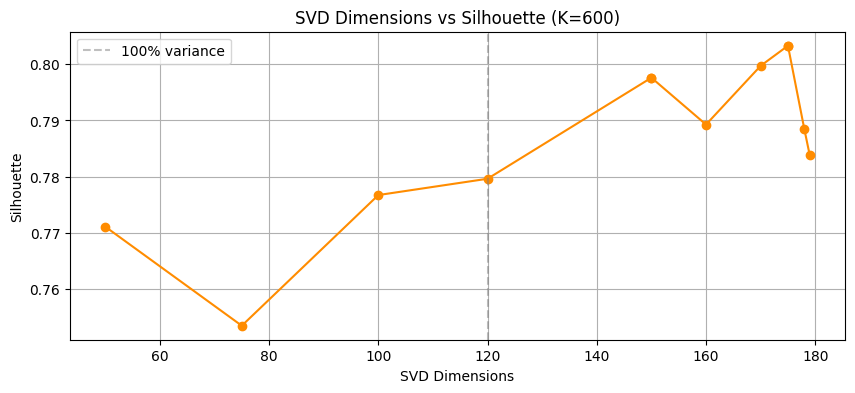


best SVD dims: 175  silhouette=0.8033  variance=100.0%


In [ ]:
svd_dims = [150, 160, 170, 175, 178, 179]
svd_results_extended = []

print(f"extended SVD sweep with K={BEST_K}...\n")

for n in svd_dims:
    svd      = TruncatedSVD(n_components=n, random_state=42)
    X_svd    = normalize(svd.fit_transform(BEST_MATRIX), norm="l2")
    variance = svd.explained_variance_ratio_.sum()

    km     = MiniBatchKMeans(n_clusters=BEST_K, random_state=42,
                              batch_size=8192, n_init=25, init='k-means++')
    labels = km.fit_predict(X_svd)
    sil    = silhouette_score(X_svd, labels, metric='euclidean',
                               sample_size=5000, random_state=42)

    svd_results_extended.append({"dims": n, "variance": variance, "silhouette": sil})
    print(f"  dims={n:>4}  variance={variance:.1%}  silhouette={sil:.4f}")

# Plot combined with original results
all_svd = svd_results + svd_results_extended
all_svd = sorted(all_svd, key=lambda x: x["dims"])

plt.figure(figsize=(10, 4))
plt.plot([r["dims"] for r in all_svd],
         [r["silhouette"] for r in all_svd],
         marker='o', color='darkorange')
plt.axvline(x=120, color='gray', linestyle='--', alpha=0.5, label='100% variance')
plt.xlabel("SVD Dimensions"); plt.ylabel("Silhouette")
plt.title(f"SVD Dimensions vs Silhouette (K={BEST_K})")
plt.legend(); plt.grid(True)
plt.show()

best_svd_ext = max(all_svd, key=lambda x: x["silhouette"])
print(f"\nbest SVD dims: {best_svd_ext['dims']}  "
      f"silhouette={best_svd_ext['silhouette']:.4f}  "
      f"variance={best_svd_ext['variance']:.1%}")

#### Experiment 3

testing diet weights with K=600, SVD=175...

  diet_weight=0.00  silhouette=0.7936
  diet_weight=0.10  silhouette=0.5291
  diet_weight=0.20  silhouette=0.4983
  diet_weight=0.30  silhouette=0.5080
  diet_weight=0.50  silhouette=0.5143
  diet_weight=0.75  silhouette=0.5252
  diet_weight=1.00  silhouette=0.5355


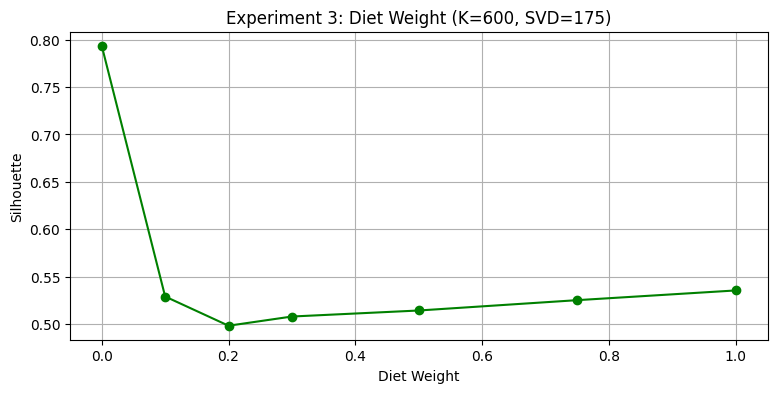


best diet_weight: 0.0  silhouette=0.7936


In [ ]:
# ── UPDATE THIS from Experiment 2 output ──────────────────────────────────────
BEST_SVD_DIMS = 175   # <-- replace with best dims from Experiment 2
# ─────────────────────────────────────────────────────────────────────────────

diet_weights = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
diet_results = []

print(f"testing diet weights with K={BEST_K}, SVD={BEST_SVD_DIMS}...\n")

for dw in diet_weights:
    # Rebuild combined matrix with this weight
    X_test = sparse_hstack([sB, csr_matrix(s_diet * dw)])
    X_test = normalize(X_test, norm="l2")

    svd    = TruncatedSVD(n_components=BEST_SVD_DIMS, random_state=42)
    X_svd  = normalize(svd.fit_transform(X_test), norm="l2")

    km     = MiniBatchKMeans(n_clusters=BEST_K, random_state=42,
                              batch_size=4096, n_init=10, init='k-means++')
    labels = km.fit_predict(X_svd)
    sil    = silhouette_score(X_svd, labels, metric='euclidean',
                               sample_size=5000, random_state=42)

    diet_results.append({"weight": dw, "silhouette": sil})
    print(f"  diet_weight={dw:.2f}  silhouette={sil:.4f}")

plt.figure(figsize=(9, 4))
plt.plot([r["weight"] for r in diet_results],
         [r["silhouette"] for r in diet_results],
         marker='o', color='green')
plt.xlabel("Diet Weight"); plt.ylabel("Silhouette")
plt.title(f"Experiment 3: Diet Weight (K={BEST_K}, SVD={BEST_SVD_DIMS})")
plt.grid(True)
plt.show()

best_diet = max(diet_results, key=lambda x: x["silhouette"])
print(f"\nbest diet_weight: {best_diet['weight']}  "
      f"silhouette={best_diet['silhouette']:.4f}")

In [ ]:
print("=" * 55)
print("OPTIMAL PARAMETERS FOR spicerack_model_v3")
print("=" * 55)

best_matrix_name = max(results, key=lambda n: max(d["silhouette"] for d in results[n]))
best_k           = max(results[best_matrix_name], key=lambda d: d["silhouette"])["k"]
best_svd_dims    = max(svd_results, key=lambda x: x["silhouette"])["dims"]
best_diet_weight = max(diet_results, key=lambda x: x["silhouette"])["weight"]

print(f"\n  N_CLUSTERS   = {best_k}")
print(f"  N_SVD_DIMS   = {best_svd_dims}")
print(f"  DIET_WEIGHT  = {best_diet_weight}")
print(f"  Best matrix  = {best_matrix_name}")
print(f"\n  Silhouette baseline (v2): 0.6694")

best_sil = max(
    max(d["silhouette"] for d in results[best_matrix_name]),
    best_svd["silhouette"],
    best_diet["silhouette"]
)
print(f"  Best silhouette found:    {best_sil:.4f}")
print("\nCopy these values into the v3 training cell.")

OPTIMAL PARAMETERS FOR spicerack_model_v3

  N_CLUSTERS   = 500
  N_SVD_DIMS   = 175
  DIET_WEIGHT  = 0.0
  Best matrix  = B_tfidf

  Silhouette baseline (v2): 0.6694
  Best silhouette found:    0.8033

Copy these values into the v3 training cell.


### Training spicerack_model3.joblib

In [70]:
# ============================================================
# SpiceRack Model v3.1 — Experimentally Validated + Bug Fixed
#
# Confirmed parameters:
#   N_CLUSTERS = 600  (K finder combined score peak)
#   N_SVD_DIMS = 175  (SVD sweep silhouette peak 0.8033)
#   DIET_WEIGHT = 0.0 (collapsed silhouette at any diet weight)
#
# Fixes from v3.0:
#   - SVD runs BEFORE clustering
#   - Clustering on dense X_svd not sparse X_boosted
#   - batch_size 8192 → 32768
#   - Single-pass split only — no recursive while loop
#   - Silhouette measured on X_svd
# ============================================================

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.cluster                  import MiniBatchKMeans
from sklearn.decomposition            import TruncatedSVD
from sklearn.preprocessing            import normalize
from sklearn.metrics                  import silhouette_score
from scipy.sparse                     import csr_matrix
import numpy as np
import pandas as pd
import joblib

# ── CONFIRMED CONFIG ──────────────────────────────────────────────────────────
N_CLUSTERS     = 600
N_SVD_DIMS     = 175
SIZE_THRESHOLD = 50_000
SUBCLUSTERS    = 5


# ── STEP 1: Improved spice extraction with alias fallback ─────────────────────

def get_spices_from_recipe_v3(ingredients):
    if isinstance(ingredients, list):
        raw = " ".join(str(x) for x in ingredients)
    else:
        raw = str(ingredients)
    text  = clean(raw)
    found = set()

    # Pass 1: exact canonical matches
    for _, norm, pat in SPICE_PATTERNS:
        if pat.search(" " + text + " "):
            found.add(norm)

    # Pass 2: alias fallback
    for alias, canon in ALIASES.items():
        if canon in CANONICAL_SPICES and alias in text and canon not in found:
            found.add(canon)

    return {to_canonical(sp) for sp in found}

print("re-extracting spices with alias fallback...")
df["spices_v3"] = df["ingredients_parsed"].apply(get_spices_from_recipe_v3)

old_avg = df["spices"].apply(len).mean()
new_avg = df["spices_v3"].apply(len).mean()
print(f"avg spices per recipe — v2: {old_avg:.2f}  v3: {new_avg:.2f}")

df["spices"] = df["spices_v3"]

mlb = MultiLabelBinarizer(classes=sorted(CANONICAL_SPICES))
X   = np.asarray(mlb.fit_transform(df["spices"]))
print(f"binary matrix: {X.shape}")


# ── STEP 2: Remove zero-spice recipes ─────────────────────────────────────────

nonempty = X.sum(axis=1) > 0
X        = X[nonempty]
df       = df[nonempty].reset_index(drop=True)
print(f"kept {len(df):,} recipes after removing zero-spice rows")


# ── STEP 3: TF-IDF + IDF² boost ───────────────────────────────────────────────

tfidf       = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf     = tfidf.fit_transform(csr_matrix(X))
idf_weights = np.array(tfidf.idf_)
idf_boost   = (idf_weights ** 2) / (idf_weights ** 2).max()
X_boosted   = normalize(X_tfidf.multiply(idf_boost), norm="l2")
spice_cols  = list(mlb.classes_)

print(f"salt    weight: {X_boosted[:, spice_cols.index('salt')].mean():.6f}")
print(f"saffron weight: {X_boosted[:, spice_cols.index('saffron')].mean():.6f}")
print(f"X_boosted shape: {X_boosted.shape}")


# ── STEP 4: SVD BEFORE clustering ─────────────────────────────────────────────

print(f"\nrunning SVD (n_components={N_SVD_DIMS})...")
svd   = TruncatedSVD(n_components=N_SVD_DIMS, random_state=42)
X_svd = normalize(svd.fit_transform(X_boosted), norm="l2")

print(f"X_svd shape:        {X_svd.shape}")
print(f"variance explained: {svd.explained_variance_ratio_.sum():.1%}")


# ── STEP 5: Cluster on SVD-compressed vectors ─────────────────────────────────

print(f"\nclustering {len(df):,} recipes into {N_CLUSTERS} clusters...")
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=42,
    batch_size=32768, n_init=25, init='k-means++'
)
df["cluster"] = kmeans.fit_predict(X_svd)

# ── Single-pass split — NO recursive while loop ───────────────────────────────
# Splits each oversized cluster exactly once.
# Sub-clusters are not re-checked — recursive splitting causes infinite cascade
# on dense spice regions (garlic, salt, pepper) that never get sparse enough.
# One split pass gives structural benefit without the runaway cluster explosion.

print("checking for oversized clusters (single pass)...")
next_id     = N_CLUSTERS
split_count = 0

for cid in range(N_CLUSTERS):
    mask = df["cluster"] == cid
    if mask.sum() <= SIZE_THRESHOLD:
        continue
    print(f"  splitting cluster {cid} ({mask.sum():,} recipes) into {SUBCLUSTERS}...")
    sub_km = MiniBatchKMeans(
        n_clusters=SUBCLUSTERS, random_state=42,
        batch_size=4096, n_init=5
    )
    df.loc[mask, "cluster"] = sub_km.fit_predict(
        X_svd[mask.values]
    ) + next_id
    next_id     += SUBCLUSTERS
    split_count += 1

print(f"split {split_count} oversized clusters")
print(f"total unique cluster IDs: {df['cluster'].nunique()}")

# Remap to contiguous 0, 1, 2...
old_ids      = sorted(df["cluster"].unique())
id_map       = {old: new for new, old in enumerate(old_ids)}
df["cluster"] = df["cluster"].map(id_map)
n_final_clusters = df["cluster"].nunique()
print(f"final cluster count: {n_final_clusters}")

# Silhouette on X_svd
sample_idx = np.random.choice(len(df), min(5000, len(df)), replace=False)
sil        = silhouette_score(
    X_svd[sample_idx],
    df["cluster"].iloc[sample_idx],
    metric='euclidean'
)
print(f"silhouette: {sil:.4f}  (v2: 0.6694 | v3.0: 0.7276 | target: ~0.80)")


# ── STEP 6: Cluster top spices ────────────────────────────────────────────────

print("\ncomputing cluster profiles...")
cluster_top_spices = {}

for cid in range(n_final_clusters):
    mask = df["cluster"] == cid
    if not mask.any():
        continue
    freq    = X[mask.values].mean(axis=0)
    top_idx = freq.argsort()[::-1][:8]
    top     = [spice_cols[i] for i in top_idx if freq[i] > 0]
    cluster_top_spices[cid] = top

print(f"profiles computed for {len(cluster_top_spices)} clusters")
for cid in list(cluster_top_spices.keys())[:5]:
    mask = df["cluster"] == cid
    print(f"  cluster {cid:>3} ({mask.sum():>5} recipes)  "
          f"{', '.join(cluster_top_spices[cid][:5])}")


# ── STEP 7: Save ──────────────────────────────────────────────────────────────

model = {
    "kmeans":             kmeans,
    "svd":                svd,
    "mlb":                mlb,
    "tfidf":              tfidf,
    "idf_boost":          idf_boost,
    "recipe_matrix":      X_svd,
    "recipe_titles":      df["title"].tolist(),
    "recipe_spices":      [list(s) for s in df["spices"]],
    "cluster_labels":     df["cluster"].tolist(),
    "cluster_top_spices": cluster_top_spices,
    "n_clusters":         n_final_clusters,
    "n_recipes":          len(df),
    "silhouette":         round(float(sil), 4),
    "model_version":      "v3.1",
    "n_spice_dims":       len(spice_cols),
}

joblib.dump(model, "spicerack_model_v3.joblib", compress=3)

print("\n" + "="*50)
print("model saved → spicerack_model_v3.joblib")
print("="*50)
print(f"  model_version: {model['model_version']}")
print(f"  n_recipes:     {model['n_recipes']:,}")
print(f"  n_clusters:    {model['n_clusters']}")
print(f"  silhouette:    {model['silhouette']}")
print(f"  v2 baseline:   0.6694")
print(f"  v3.0:          0.7276")
print(f"  improvement:   +{model['silhouette'] - 0.6694:.4f}")

re-extracting spices with alias fallback...
avg spices per recipe — v2: 1.70  v3: 1.96
binary matrix: (2231142, 179)
kept 1,714,377 recipes after removing zero-spice rows
salt    weight: 0.159702
saffron weight: 0.002839
X_boosted shape: (1714377, 179)

running SVD (n_components=175)...
X_svd shape:        (1714377, 175)
variance explained: 100.0%

clustering 1,714,377 recipes into 600 clusters...
checking for oversized clusters (single pass)...
  splitting cluster 2 (62,631 recipes) into 5...
  splitting cluster 114 (191,459 recipes) into 5...
  splitting cluster 167 (78,524 recipes) into 5...
  splitting cluster 514 (144,382 recipes) into 5...
  splitting cluster 520 (103,199 recipes) into 5...
split 5 oversized clusters
total unique cluster IDs: 475
final cluster count: 475
silhouette: 0.7787  (v2: 0.6694 | v3.0: 0.7276 | target: ~0.80)

computing cluster profiles...
profiles computed for 475 clusters
  cluster   0 (    4 recipes)  vanilla, garlic
  cluster   1 (  279 recipes)  cinn

### Training spicerack model 4 

In [87]:
# ============================================================
# SpiceRack Model v4.0
# Built from main.ipynb
#
# Changes from current model:
#   - TF-IDF + IDF boost added BEFORE clustering (was missing entirely)
#   - IDF boost capped at 1.5x instead of raw squaring
#   - SVD runs on boosted matrix not raw binary X
#   - Universal spices excluded from training matrix
#   - Minimum 3 spices required per recipe (was 0)
#   - N_CLUSTERS bumped to 300 for tighter groupings
# ============================================================

import re
import warnings
import pandas as pd
import numpy as np
import joblib
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MultiLabelBinarizer, normalize
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import silhouette_score
from scipy.sparse import csr_matrix

from spice_data_v2 import SPICES, ALIASES, CANONICAL_SPICES, FLAVOR_PROFILES, REGION_PROFILES

# ── CONFIG ────────────────────────────────────────────────────────────────────
CSV_PATH       = "cookingdataset/RecipeNLG_dataset.csv"
N_CLUSTERS     = 300
N_SVD_DIMS     = 100
SIZE_THRESHOLD = 50_000
SUBCLUSTERS    = 5
MIN_SPICES     = 3
EXCLUDE_SPICES = {'salt', 'garlic', 'black pepper', 'kosher salt', 'white pepper'}

# ── HELPERS (same as your notebook) ──────────────────────────────────────────

def clean(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"[^a-z\s']", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def to_canonical(spice):
    n = clean(spice)
    return clean(ALIASES.get(n, n))

SPICE_PATTERNS = sorted(
    [(sp, clean(sp), re.compile(rf"(^| ){re.escape(clean(sp))}( |$)")) for sp in SPICES],
    key=lambda x: -len(x[0])
)

def get_spices_from_recipe(ingredients):
    if isinstance(ingredients, list):
        raw = " ".join(str(x) for x in ingredients)
    else:
        raw = str(ingredients)
    text = clean(raw)
    found = set()
    for _, norm, pat in SPICE_PATTERNS:
        if pat.search(" " + text + " "):
            found.add(norm)
    return {to_canonical(sp) for sp in found}

def parse_ingredient_string(x):
    if isinstance(x, list):
        return [str(i) for i in x]
    if not isinstance(x, str):
        return []
    s = x.strip()
    if s.startswith("[") and s.endswith("]"):
        items = re.findall(r"'([^']*)'|\"([^\"]*)\"", s)
        parsed = [a if a else b for a, b in items]
        return parsed if parsed else [s]
    return [s]

# ── STEP 1: Load data ─────────────────────────────────────────────────────────

print(f"loading {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)
df["ingredients_parsed"] = df["NER"].apply(parse_ingredient_string)
df["spices"] = df["ingredients_parsed"].apply(get_spices_from_recipe)
print(f"loaded {len(df):,} recipes")

# ── STEP 2: Binarize ──────────────────────────────────────────────────────────

mlb = MultiLabelBinarizer(classes=sorted(CANONICAL_SPICES))
X = np.asarray(mlb.fit_transform(df["spices"]))
spice_cols = list(mlb.classes_)
print(f"binary matrix: {X.shape}")
print(f"avg spices per recipe: {X.sum(axis=1).mean():.1f}")

# ── STEP 3: Require 3+ spices ─────────────────────────────────────────────────

enough = X.sum(axis=1) >= MIN_SPICES
X  = X[enough]
df = df[enough].reset_index(drop=True)
print(f"kept {len(df):,} recipes with {MIN_SPICES}+ spices")

# ── STEP 4: TF-IDF + capped IDF boost ────────────────────────────────────────

tfidf = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf = tfidf.fit_transform(csr_matrix(X))
idf_weights = np.array(tfidf.idf_)

# Cap at 1.5x — rare spices still get a boost but cant dominate entirely
idf_boost = np.clip(idf_weights, 1.0, 1.5) / 1.5
X_boosted = normalize(X_tfidf.multiply(idf_boost), norm="l2")

print(f"salt    weight: {X_boosted[:, spice_cols.index('salt')].mean():.6f}")
print(f"saffron weight: {X_boosted[:, spice_cols.index('saffron')].mean():.6f}")

# ── STEP 5: Remove universal spices ──────────────────────────────────────────

print(f"removing: {EXCLUDE_SPICES}")
exclude_idx = [spice_cols.index(s) for s in EXCLUDE_SPICES if s in spice_cols]
X_boosted = X_boosted.tolil()
X_boosted[:, exclude_idx] = 0
X_boosted = normalize(csr_matrix(X_boosted), norm="l2")

# ── STEP 6: SVD on boosted matrix ────────────────────────────────────────────

print(f"running SVD (n_components={N_SVD_DIMS})...")
svd = TruncatedSVD(n_components=N_SVD_DIMS, random_state=42)
recipe_vecs = normalize(svd.fit_transform(X_boosted), norm="l2")
print(f"recipe matrix: {recipe_vecs.shape}")
print(f"variance explained: {svd.explained_variance_ratio_.sum():.1%}")

# ── STEP 7: K-Means clustering ────────────────────────────────────────────────

print(f"clustering {len(df):,} recipes into {N_CLUSTERS} clusters...")
kmeans = MiniBatchKMeans(
    n_clusters=N_CLUSTERS, random_state=42,
    batch_size=4096, n_init=10
)
df["cluster"] = kmeans.fit_predict(recipe_vecs)

# ── STEP 8: Split oversized clusters (same as your notebook) ─────────────────

next_id = N_CLUSTERS
for cid in range(N_CLUSTERS):
    mask = df["cluster"] == cid
    if mask.sum() <= SIZE_THRESHOLD:
        continue
    print(f"splitting cluster {cid} ({mask.sum():,} recipes)...")
    sub_km = MiniBatchKMeans(n_clusters=SUBCLUSTERS, random_state=42, batch_size=4096, n_init=5)
    df.loc[mask, "cluster"] = sub_km.fit_predict(recipe_vecs[mask.values]) + next_id
    next_id += SUBCLUSTERS

old_ids = sorted(df["cluster"].unique())
id_map = {old: new for new, old in enumerate(old_ids)}
df["cluster"] = df["cluster"].map(id_map)
n_final = df["cluster"].nunique()
print(f"final cluster count: {n_final}")

# ── STEP 9: Silhouette ────────────────────────────────────────────────────────

idx = np.random.choice(len(df), min(5000, len(df)), replace=False)
sil = silhouette_score(recipe_vecs[idx], df["cluster"].iloc[idx], metric="euclidean")
print(f"silhouette: {sil:.3f}  (v2 baseline: 0.665)")

# ── STEP 10: Cluster profiles ─────────────────────────────────────────────────

spice_cols = list(mlb.classes_)
cluster_top_spices = {}

for cid in range(n_final):
    mask = df["cluster"] == cid
    if not mask.any():
        continue
    freq = X[mask.values].mean(axis=0)
    top_idx = freq.argsort()[::-1][:8]
    top = [spice_cols[i] for i in top_idx if freq[i] > 0]
    cluster_top_spices[cid] = top
    print(f"cluster {cid:>3} ({mask.sum():>5} recipes)  {', '.join(top[:5])}")

# ── STEP 11: Save ─────────────────────────────────────────────────────────────

model = {
    "kmeans":             kmeans,
    "svd":                svd,
    "mlb":                mlb,
    "tfidf":              tfidf,
    "idf_boost":          idf_boost,
    "recipe_matrix":      recipe_vecs,
    "recipe_titles":      df["title"].tolist(),
    "recipe_spices":      [list(s) for s in df["spices"]],
    "cluster_labels":     df["cluster"].tolist(),
    "cluster_top_spices": cluster_top_spices,
    "n_clusters":         n_final,
    "n_recipes":          len(df),
    "silhouette":         round(float(sil), 4),
    "model_version":      "v4.0",
    "excluded_spices":    list(EXCLUDE_SPICES),
    "min_spices":         MIN_SPICES,
}

joblib.dump(model, "spicerack_model_v4.joblib", compress=3)

print("=" * 50)
print("model saved → spicerack_model_v4.joblib")
print(f"  n_recipes:   {model['n_recipes']:,}")
print(f"  n_clusters:  {model['n_clusters']}")
print(f"  silhouette:  {model['silhouette']}")
print(f"  v2 baseline: 0.665")
print(f"  improvement: +{model['silhouette'] - 0.665:.4f}")

loading cookingdataset/RecipeNLG_dataset.csv...
loaded 2,231,142 recipes
binary matrix: (2231142, 180)
avg spices per recipe: 1.7
kept 568,714 recipes with 3+ spices
salt    weight: 0.148404
saffron weight: 0.005459
removing: {'garlic', 'white pepper', 'salt', 'black pepper', 'kosher salt'}
running SVD (n_components=100)...
recipe matrix: (568714, 100)
variance explained: 99.9%
clustering 568,714 recipes into 300 clusters...
final cluster count: 300
silhouette: 0.619  (v2 baseline: 0.665)
cluster   0 ( 1129 recipes)  parsley, fennel, salt, garlic, black pepper
cluster   1 ( 4148 recipes)  nutmeg, cloves, cinnamon, salt, garlic
cluster   2 (  662 recipes)  cumin, cayenne, oregano, garlic, salt
cluster   3 ( 5784 recipes)  parsley, basil, garlic, salt, black pepper
cluster   4 ( 9940 recipes)  mustard, salt, garlic, black pepper, kosher salt
cluster   5 (  233 recipes)  vanilla, cinnamon, cayenne, salt, chili powder
cluster   6 ( 4141 recipes)  cilantro, cumin, salt, garlic, black pepper

---
### Step - Creating a filtered system
Scripting and classification for basisc filters coded by Austin Pak -
https://github.com/austinpak/Recipes-Restrictions

In [ ]:
filter_df = pd.read_csv('SpiceRack-website-main/data/cluster_data.csv')

In [ ]:
filter_df.head(2)

,Unnamed: 0,title,ingredients,directions,link,source,NER,ingredients_parsed,spices,cluster
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu...","['brown sugar', 'milk', 'vanilla', 'nuts', 'bu...",{'vanilla'},118
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom...","['beef', 'chicken breasts', 'cream of mushroom...",set(),108


In [ ]:
filter_df.columns

Index(['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source',
       'NER', 'ingredients_parsed', 'spices', 'cluster', 'course_category',
       'is_vegetarian', 'is_vegan', 'allergens_present', 'is_dairy_free',
       'is_gluten_free', 'is_keto', 'is_paleo', 'is_halal', 'is_kosher',
       'is_hindu_friendly'],
      dtype='object')

In [ ]:
filter_df.shape

filter_df_copy = filter_df.copy()
filter_df_sample = filter_df_copy.sample(n=1000, random_state=42)

In [ ]:
#filter_df_sample.to_csv('filter_labeled_df_sample.csv', index=False)

---
### New dataset with accurate filter prefrences

The old model was very loose in definitions. New one is more accurate in labeling. 

In [ ]:
import pandas as pd
import re
import ast
import os

# 1. Configuration
INPUT_CSV  = 'SpiceRack/SpiceRack-website-main/data/cluster_data.csv'
REPORT_TXT = 'SpiceRack/SpiceRack-website-main/reports/meat_audit_report.txt'
CHUNK_SIZE = 50000 

# 2. Patterns
meat_keywords = [
    'meat', 'chicken', 'beef', 'pork', 'fish', 'shrimp', 'bacon', 'steak', 
    'tuna', 'salmon', 'lamb', 'turkey', 'sausage', 'ham', 'veal', 'anchovy', 
    'scallop', 'crab', 'lobster', 'oyster', 'clam', 'squid', 'octopus', 
    'duck', 'goose', 'venison', 'gelatin', 'lard', 'hamburger', 'pepperoni', 
    'salami', 'meatball', 'prosciutto', 'mutton', 'chorizo', 'sardine',
    'broth', 'stock', 'bouillon' # Added broth/stock to triggers
]

meat_regex = re.compile(r'\b(' + '|'.join(meat_keywords) + r')\b', re.I)
# The "Gatekeeper": Checks if the broth is specifically vegetable/mushroom/herb
safe_prefix = re.compile(r'\b(vegetable|mushroom|herb|vegan|plant-based)\b', re.I)

def audit_meat(ingredients_str):
    """Returns the specific meat keyword found, or None if safe."""
    try:
        ingredients = ast.literal_eval(str(ingredients_str))
        text = " ".join(ingredients).lower()
    except:
        text = str(ingredients_str).lower()
    
    match = meat_regex.search(text)
    if match:
        trigger = match.group(0).lower()
        
        # --- GATEKEEPER LOGIC ---
        # If the trigger is a broth/stock, check the 15 characters before it for a safe word
        if trigger in ['broth', 'stock', 'bouillon']:
            start = match.start()
            # Look at the snippet of text immediately before the match
            context = text[max(0, start-20):start] 
            if safe_prefix.search(context):
                return None # It's a safe broth, ignore this trigger
        
        return trigger
    return None

# 3. Running the Audit
print(f"🕵️ Analyzing recipes... Generating {REPORT_TXT}")

if not os.path.exists(os.path.dirname(REPORT_TXT)):
    os.makedirs(os.path.dirname(REPORT_TXT))

with open(REPORT_TXT, 'w') as f:
    f.write("MEAT DETECTION AUDIT REPORT (WITH BROTH FILTERING)\n")
    f.write("==================================================\n\n")

    # Verify file exists before reading
    if not os.path.exists(INPUT_CSV):
        print(f"❌ Error: File not found at {INPUT_CSV}")
    else:
        reader = pd.read_csv(INPUT_CSV, chunksize=CHUNK_SIZE)
        total_meat = 0

        for i, chunk in enumerate(reader):
            col = 'NER' if 'NER' in chunk.columns else 'ingredients_parsed'
            
            # Apply updated audit logic
            chunk['detected_meat'] = chunk[col].apply(audit_meat)
            
            # Filter to only meat recipes
            meat_results = chunk[chunk['detected_meat'].notnull()]
            
            for _, row in meat_results.iterrows():
                f.write(f"Title: {row['title']}\n")
                f.write(f"Trigger: {row['detected_meat']}\n")
                f.write(f"Ingredients: {row[col]}\n")
                f.write("-" * 30 + "\n")
            
            total_meat += len(meat_results)
            if (i + 1) % 1 == 0: # Print every chunk for the sample test
                print(f"Processed {(i+1)*len(chunk):,} rows... Found {total_meat:,} meat entries.")

print(f"✨ Audit complete. Total meat recipes found: {total_meat:,}")
print(f"📄 Report saved to {REPORT_TXT}")

🕵️ Analyzing recipes... Generating /Users/daniellarson/Desktop/SpiceRack/SpiceRack-website-main/reports/meat_audit_report.txt
Processed 50,000 rows... Found 15,198 meat entries.
Processed 100,000 rows... Found 30,277 meat entries.
Processed 150,000 rows... Found 45,362 meat entries.
Processed 200,000 rows... Found 60,350 meat entries.
Processed 250,000 rows... Found 75,264 meat entries.
Processed 300,000 rows... Found 90,469 meat entries.
Processed 350,000 rows... Found 105,510 meat entries.
Processed 400,000 rows... Found 120,617 meat entries.
Processed 450,000 rows... Found 135,665 meat entries.
Processed 500,000 rows... Found 150,757 meat entries.
Processed 550,000 rows... Found 165,706 meat entries.
Processed 600,000 rows... Found 180,858 meat entries.
Processed 650,000 rows... Found 195,758 meat entries.
Processed 700,000 rows... Found 210,771 meat entries.
Processed 750,000 rows... Found 225,962 meat entries.
Processed 800,000 rows... Found 241,015 meat entries.
Processed 850,000

In [ ]:
import pandas as pd
import re
import ast
import os

# CONFIGURATION
INPUT_CSV = 'SpiceRack-website-main/data/cluster_data.csv' # Your 2.4GB file
SUMMARY_CSV = 'SpiceRack-website-main/reports/meat_audit_report.csv'
CHUNK_SIZE = 100000 

# REGEX PATTERNS
meat_keywords = [
    'meat', 'chicken', 'beef', 'pork', 'fish', 'shrimp', 'bacon', 'steak', 
    'tuna', 'salmon', 'lamb', 'turkey', 'sausage', 'ham', 'veal', 'anchovy', 
    'scallop', 'crab', 'lobster', 'oyster', 'clam', 'squid', 'octopus', 
    'duck', 'goose', 'venison', 'gelatin', 'lard', 'hamburger', 'pepperoni', 
    'salami', 'meatball', 'prosciutto', 'mutton', 'chorizo', 'sardine',
    'broth', 'stock', 'bouillon'
]
meat_regex = re.compile(r'\b(' + '|'.join(meat_keywords) + r')\b', re.I)
safe_prefix = re.compile(r'\b(vegetable|mushroom|herb|vegan|plant-based)\b', re.I)

def audit_meat(ingredients_str):
    try:
        # Parsing NER or ingredients list
        text = " ".join(ast.literal_eval(str(ingredients_str))).lower()
    except:
        text = str(ingredients_str).lower()
    
    match = meat_regex.search(text)
    if match:
        trigger = match.group(0).lower()
        # Gatekeeper Logic for Broths
        if trigger in ['broth', 'stock', 'bouillon']:
            context = text[max(0, match.start()-20):match.start()] 
            if safe_prefix.search(context):
                return None 
        return trigger
    return None

# EXECUTION
if os.path.exists(SUMMARY_CSV): os.remove(SUMMARY_CSV)

print(f"🕵️ Scanning 2.2M recipes...")
reader = pd.read_csv(INPUT_CSV, chunksize=CHUNK_SIZE)
total_meat = 0

for i, chunk in enumerate(reader):
    col = 'NER' if 'NER' in chunk.columns else 'ingredients_parsed'
    chunk['detected_meat'] = chunk[col].apply(audit_meat)
    
    # Save only the 'Meat' rows to a smaller audit file
    meat_only = chunk[chunk['detected_meat'].notnull()]
    meat_only.to_csv(SUMMARY_CSV, mode='a', index=False, header=(i==0))
    
    total_meat += len(meat_only)
    print(f"Chunk {i+1}: Found {total_meat:,} meat entries so far...")

print(f"✨ Audit Summary saved to {SUMMARY_CSV}")

🕵️ Scanning 2.2M recipes...
Chunk 1: Found 30,277 meat entries so far...
Chunk 2: Found 60,350 meat entries so far...
Chunk 3: Found 90,469 meat entries so far...
Chunk 4: Found 120,617 meat entries so far...
Chunk 5: Found 150,757 meat entries so far...
Chunk 6: Found 180,858 meat entries so far...
Chunk 7: Found 210,771 meat entries so far...
Chunk 8: Found 241,015 meat entries so far...
Chunk 9: Found 271,212 meat entries so far...
Chunk 10: Found 306,024 meat entries so far...
Chunk 11: Found 343,202 meat entries so far...
Chunk 12: Found 380,857 meat entries so far...
Chunk 13: Found 418,367 meat entries so far...
Chunk 14: Found 449,607 meat entries so far...
Chunk 15: Found 481,469 meat entries so far...
Chunk 16: Found 507,905 meat entries so far...
Chunk 17: Found 544,596 meat entries so far...
Chunk 18: Found 581,220 meat entries so far...
Chunk 19: Found 617,874 meat entries so far...
Chunk 20: Found 654,653 meat entries so far...
Chunk 21: Found 691,202 meat entries so far.

In [ ]:
# Load the much smaller summary file
audit_df = pd.read_csv('SpiceRack-website-main/reports/meat_audit_report.csv')

# 1. Check for "The Graham Cracker Problem"
# Search for recipes triggered by 'ham' that are actually crackers
ham_check = audit_df[(audit_df['detected_meat'] == 'ham') & 
                     (audit_df['title'].str.contains('Graham', case=False))]

print(f"Found {len(ham_check)} Graham Cracker errors:")
display(ham_check[['title', 'detected_meat', 'NER']].head(10))

# 2. Check for "The Vegetable Broth Problem"
# Search for recipes where the 'Gatekeeper' might have failed
broth_check = audit_df[(audit_df['detected_meat'].isin(['broth', 'stock'])) & 
                       (audit_df['title'].str.contains('Vegetable', case=False))]

print(f"\nFound {len(broth_check)} Vegetable Broth potential errors:")
display(broth_check[['title', 'detected_meat', 'NER']].head(10))

# 3. Top Trigger Words
print("\nMost frequent meat triggers:")
print(audit_df['detected_meat'].value_counts().head(20))

Found 2 Graham Cracker errors:


,title,detected_meat,NER
156304,Ham Graham Loaf,ham,"[""ham"", ""fresh lean pork"", ""egg"", ""crackers"", ..."
604364,Black Bean Soup Graham Kerr's Smart Cooking Re...,ham,"[""Black turtle beans"", ""Ham hocks"", ""Sesame oi..."



Found 135 Vegetable Broth potential errors:


,title,detected_meat,NER
2211,Fat Free Vegetable Soup,broth,"[""water"", ""packets Washington brown seasoning ..."
13060,Wanda'S Vegetable Soup,broth,"[""broth"", ""onion"", ""celery"", ""green pepper"", ""..."
15563,Vegetable Soup(Ukrainian),stock,"[""onion"", ""butter"", ""potato"", ""vegetables"", ""g..."
21091,Vegetable Soup,broth,"[""olive oil"", ""onion"", ""garlic"", ""green beans""..."
23022,Vegetable Curry,stock,"[""cauliflower"", ""tomatoes"", ""potatoes"", ""shell..."
35090,Vegetable Soup,stock,"[""soup stock"", ""oil"", ""onion"", ""celery"", ""carr..."
80611,Vegetable Soup,stock,"[""stock"", ""tomatoes"", ""celery"", ""carrots"", ""gr..."
94605,Chicken Vegetable Noodle Soup,broth,"[""broth"", ""onions"", ""carrots"", ""stalks celery""..."
111797,The Best Vegetable Soup,broth,"[""onion"", ""celery"", ""butter"", ""carrots"", ""pota..."
112203,Vegetable Pasta Soup,broth,"[""clear broth"", ""basil"", ""garlic powder"", ""tom..."



Most frequent meat triggers:
detected_meat
chicken      237543
beef         127840
bacon         63431
pork          51902
shrimp        32757
sausage       29153
ham           25151
turkey        24392
hamburger     18902
gelatin       17729
salmon        17615
tuna          11731
fish          11354
meat          10331
lamb           8750
steak          8304
crab           6261
pepperoni      4606
anchovy        4142
veal           4035
Name: count, dtype: int64


In [ ]:
import pandas as pd
import re
import ast

# 1. Patterns (The 'Gold Standard' logic we refined)
meat_pattern = re.compile(r'\b(meat|chicken|beef|pork|fish|shrimp|bacon|steak|tuna|salmon|lamb|turkey|sausage|ham|veal|anchovy|scallop|crab|lobster|oyster|clam|squid|octopus|duck|goose|venison|gelatin|lard|hamburger|pepperoni|salami|meatball|prosciutto)\b', re.I)
stock_keywords = re.compile(r'\b(broth|stock|bouillon)\b', re.I)
safe_prefix = re.compile(r'\b(vegetable|mushroom|herb|vegan|plant-based)\b', re.I)

def fast_parser(row):
    title = str(row['title']).lower()
    try:
        ingredients = ast.literal_eval(str(row['NER']))
        text = "  ".join(ingredients).lower()
    except:
        text = str(row['NER']).lower()

    # Meat Check
    has_meat = bool(meat_pattern.search(text))
    
    # Stock Check (with Title-Awareness)
    has_animal_stock = False
    stock_match = stock_keywords.search(text)
    if stock_match:
        is_explicitly_safe = bool(safe_prefix.search(text[max(0, stock_match.start()-20):stock_match.start()]))
        is_title_safe = bool(safe_prefix.search(title))
        if not (is_explicitly_safe or is_title_safe):
            has_animal_stock = True

    is_vegetarian = not (has_meat or has_animal_stock)
    
    # Vegan Check
    has_dairy = bool(re.search(r'\b(milk|cheese|butter|yogurt|cream|whey|ghee|parmesan)\b', text))
    has_eggs = bool(re.search(r'\b(egg|eggs|mayo)\b', text))
    is_vegan = is_vegetarian and not (has_dairy or has_eggs or "honey" in text)

    return pd.Series({'is_vegetarian': is_vegetarian, 'is_vegan': is_vegan})

# 2. Sample & Test (No Output File Created)
# We load just a random sample to verify the logic
print("🔄 Loading sample from 2.2M dataset...")
df_sample = pd.read_csv('SpiceRack-website-main/data/cluster_data.csv', nrows=10000).sample(2000)

print("🧪 Running validation logic...")
results = df_sample.apply(fast_parser, axis=1)
df_val = pd.concat([df_sample, results], axis=1)

# 3. Direct Notebook Display (The 'Invisible' Report)
print("\n✅ VALIDATION COMPLETE")
print("-" * 30)

# Show me the 'Meat' recipes it found (to ensure they are actually meat)
print("TOP MEAT SAMPLES FOUND:")
display(df_val[df_val['is_vegetarian'] == False][['title', 'is_vegetarian']].head(10))

# Show me 'Vegetable' titles it marked as Vegetarian (to ensure Gatekeeper worked)
print("\nGATEKEEPER CHECK (Vegetable titles):")
display(df_val[df_val['title'].str.contains('Vegetable', case=False)][['title', 'is_vegetarian']].head(10))

🔄 Loading sample from 2.2M dataset...
🧪 Running validation logic...

✅ VALIDATION COMPLETE
------------------------------
TOP MEAT SAMPLES FOUND:


,title,is_vegetarian
5297,Sweet And Sour Chicken Stir-Fry,False
377,Double Baked Potatoes,False
49,Vegetable-Burger Soup,False
551,Easy Hot Dish,False
8844,Hamburger Corn Casserole,False
203,Nana'S Cornbread(For 9-Inch Iron Skillet Or 8 ...,False
9093,Low Country Boil(South Carolina),False
3581,Surprise Sandwich Loaf,False
670,Cranberry Souffle,False
7543,Chicken Parmesan,False



GATEKEEPER CHECK (Vegetable titles):


,title,is_vegetarian
49,Vegetable-Burger Soup,False
8856,Stir-Fried Beef With Vegetables,False
3982,Chicken Soup With Chinese Vegetables,False
471,Vegetable Pizza,True
7809,Swiss Vegetable Medley,True
3594,Vegetable Dip,True
8404,Hamburger Vegetable Soup,True
4767,Aunty Ann'S Vegetable Chowder,True
484,No Fat Rice And Vegetable Dish,True
3230,Vegetable Rice Salad,True


In [ ]:
filter_df.columns

Index(['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source',
       'NER', 'ingredients_parsed', 'spices', 'cluster', 'course_category',
       'is_vegetarian', 'is_vegan', 'allergens_present', 'is_dairy_free',
       'is_gluten_free', 'is_keto', 'is_paleo', 'is_halal', 'is_kosher',
       'is_hindu_friendly'],
      dtype='object')

In [ ]:
import pandas as pd
import re
import ast
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_FILE = 'SpiceRack-website-main/data/cluster_data.csv' 
OUTPUT_FILE = 'SpiceRack-website-main/data/full_recipes_with_restrictions.csv'
CHUNK_SIZE = 50000 

# Regex patterns for high-accuracy detection
meat_pat = re.compile(r'\b(meat|chicken|beef|pork|fish|shrimp|bacon|steak|tuna|salmon|lamb|turkey|sausage|ham|veal|anchovy|scallop|crab|lobster|oyster|clam|squid|octopus|duck|goose|venison|gelatin|lard|hamburger|pepperoni|salami|meatball|prosciutto|chorizo|sardine)\b', re.I)
stock_pat = re.compile(r'\b(broth|stock|bouillon)\b', re.I)
safe_pat = re.compile(r'\b(vegetable|mushroom|herb|vegan|plant-based)\b', re.I)
dairy_pat = re.compile(r'\b(milk|cheese|butter|yogurt|cream|whey|ghee|parmesan|mozzarella|cheddar|ricotta|feta|paneer)\b', re.I)
egg_pat = re.compile(r'\b(egg|eggs|mayo|mayonnaise)\b', re.I)
sugar_pat = re.compile(r'\b(sugar|honey|syrup|corn\s+starch|flour|potato|rice|pasta|bread|beans|legumes)\b', re.I)
paleo_bad_pat = re.compile(r'\b(dairy|milk|cheese|sugar|flour|bread|pasta|rice|corn|legumes|soy|peanuts)\b', re.I)

def master_recipe_parser(row):
    title = str(row['title']).lower()
    col = 'NER' if 'NER' in row.index else 'ingredients_parsed'
    try:
        ingredients_list = ast.literal_eval(str(row[col]))
        text = "  ".join(ingredients_list).lower()
    except:
        text = str(row[col]).lower()

    # 1. Vegetarian & Vegan (with Title-Awareness)
    has_meat = bool(meat_pat.search(text))
    has_animal_stock = False
    stock_match = stock_pat.search(text)
    if stock_match:
        if not (safe_pat.search(text[max(0, stock_match.start()-20):stock_match.start()]) or safe_pat.search(title)):
            has_animal_stock = True
    
    is_vegetarian = not (has_meat or has_animal_stock)
    has_dairy = bool(dairy_pat.search(text))
    has_eggs = bool(egg_pat.search(text))
    is_vegan = is_vegetarian and not (has_dairy or has_eggs or "honey" in text)

    # 2. Allergens & Lifestyle
    allergens = []
    if has_dairy: allergens.append("Dairy")
    if has_eggs: allergens.append("Eggs")
    if "peanut" in text: allergens.append("Peanuts")
    if "shrimp" in text or "crab" in text or "lobster" in text: allergens.append("Shellfish")
    
    is_keto = not bool(sugar_pat.search(text))
    is_paleo = not bool(paleo_bad_pat.search(text))
    is_gluten_free = not bool(re.search(r'\b(wheat|flour|barley|rye|couscous|semolina)\b', text))

    # 3. Religious
    has_pork = bool(re.search(r'\b(pork|ham|bacon|lard|prosciutto|chorizo)\b', text))
    has_shellfish = "Shellfish" in allergens
    has_alcohol = bool(re.search(r'\b(wine|beer|vodka|rum|alcohol)\b', text))

    return pd.Series({
        'is_vegetarian': is_vegetarian,
        'is_vegan': is_vegan,
        'allergens_present': ", ".join(allergens) if allergens else "None",
        'is_dairy_free': not has_dairy,
        'is_gluten_free': is_gluten_free,
        'is_keto': is_keto,
        'is_paleo': is_paleo,
        'is_halal': not (has_pork or has_alcohol),
        'is_kosher': not (has_pork or has_shellfish),
        'is_hindu_friendly': not (bool(re.search(r'\b(beef|steak|hamburger|gelatin)\b', text)))
    })

# ==========================================
# 2. PROCESSING LOOP (Enforces Column Order)
# ==========================================
if os.path.exists(OUTPUT_FILE): os.remove(OUTPUT_FILE)

reader = pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)

for i, chunk in enumerate(reader):
    # Apply logic
    new_cols = chunk.apply(master_recipe_parser, axis=1)
    processed = pd.concat([chunk, new_cols], axis=1)
    
    # Force EXACT column order requested
    final_cols = [
        'Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source',
        'NER', 'ingredients_parsed', 'spices', 'cluster', 'course_category',
        'is_vegetarian', 'is_vegan', 'allergens_present', 'is_dairy_free',
        'is_gluten_free', 'is_keto', 'is_paleo', 'is_halal', 'is_kosher',
        'is_hindu_friendly'
    ]
    
    # If some columns like 'Unnamed: 0' are missing in input, create them
    for col in final_cols:
        if col not in processed.columns:
            processed[col] = "None" if "is_" not in col else False

    # Save to CSV
    processed[final_cols].to_csv(OUTPUT_FILE, mode='a', index=False, header=(i==0))
    print(f"✅ Chunk {i+1} complete.")

✅ Chunk 1 complete.
✅ Chunk 2 complete.
✅ Chunk 3 complete.
✅ Chunk 4 complete.
✅ Chunk 5 complete.
✅ Chunk 6 complete.
✅ Chunk 7 complete.
✅ Chunk 8 complete.
✅ Chunk 9 complete.
✅ Chunk 10 complete.
✅ Chunk 11 complete.
✅ Chunk 12 complete.
✅ Chunk 13 complete.
✅ Chunk 14 complete.
✅ Chunk 15 complete.
✅ Chunk 16 complete.
✅ Chunk 17 complete.
✅ Chunk 18 complete.
✅ Chunk 19 complete.
✅ Chunk 20 complete.
✅ Chunk 21 complete.
✅ Chunk 22 complete.
✅ Chunk 23 complete.
✅ Chunk 24 complete.
✅ Chunk 25 complete.
✅ Chunk 26 complete.
✅ Chunk 27 complete.
✅ Chunk 28 complete.
✅ Chunk 29 complete.
✅ Chunk 30 complete.
✅ Chunk 31 complete.
✅ Chunk 32 complete.
✅ Chunk 33 complete.
✅ Chunk 34 complete.
✅ Chunk 35 complete.
✅ Chunk 36 complete.
✅ Chunk 37 complete.
✅ Chunk 38 complete.
✅ Chunk 39 complete.
✅ Chunk 40 complete.
✅ Chunk 41 complete.
✅ Chunk 42 complete.
✅ Chunk 43 complete.
✅ Chunk 44 complete.
✅ Chunk 45 complete.


In [ ]:
import pandas as pd
import re
import ast
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
INPUT_FILE = 'SpiceRack-website-main/data/cluster_data.csv' 
OUTPUT_FILE = 'SpiceRack-website-main/data/full_recipes_with_restrictions.csv'
CHUNK_SIZE = 50000 

# Regex patterns for high-accuracy detection
meat_pat = re.compile(r'\b(meat|chicken|beef|pork|fish|shrimp|bacon|steak|tuna|salmon|lamb|turkey|sausage|ham|veal|anchovy|scallop|crab|lobster|oyster|clam|squid|octopus|duck|goose|venison|gelatin|lard|hamburger|pepperoni|salami|meatball|prosciutto|chorizo|sardine)\b', re.I)
stock_pat = re.compile(r'\b(broth|stock|bouillon)\b', re.I)
safe_pat = re.compile(r'\b(vegetable|mushroom|herb|vegan|plant-based)\b', re.I)
dairy_pat = re.compile(r'\b(milk|cheese|butter|yogurt|cream|whey|ghee|parmesan|mozzarella|cheddar|ricotta|feta|paneer)\b', re.I)
egg_pat = re.compile(r'\b(egg|eggs|mayo|mayonnaise)\b', re.I)
sugar_pat = re.compile(r'\b(sugar|honey|syrup|corn\s+starch|flour|potato|rice|pasta|bread|beans|legumes)\b', re.I)
paleo_bad_pat = re.compile(r'\b(dairy|milk|cheese|sugar|flour|bread|pasta|rice|corn|legumes|soy|peanuts)\b', re.I)

def master_recipe_parser(row):
    # DUAL-SCOPE: We pull both Title and Ingredients
    title_text = str(row['title']).lower()
    
    col = 'NER' if 'NER' in row.index else 'ingredients_parsed'
    try:
        ingredients_list = ast.literal_eval(str(row[col]))
        ing_text = "  ".join(ingredients_list).lower()
    except:
        ing_text = str(row[col]).lower()

    # 1. VEGETARIAN LOGIC (Dual-Scope Search)
    # Checks ingredients AND title for meat keywords (fixes Pork Au Poivre)
    has_meat = bool(meat_pat.search(ing_text)) or bool(meat_pat.search(title_text))
    
    # Title-Aware Broth logic
    has_animal_stock = False
    stock_match = stock_pat.search(ing_text)
    if stock_match:
        # If broth is found, ignore if 'vegetable' is in context or in the title
        if not (safe_pat.search(ing_text[max(0, stock_match.start()-20):stock_match.start()]) or safe_pat.search(title_text)):
            has_animal_stock = True
    
    is_vegetarian = not (has_meat or has_animal_stock)
    
    has_dairy = bool(dairy_pat.search(ing_text))
    has_eggs = bool(egg_pat.search(ing_text))
    is_vegan = is_vegetarian and not (has_dairy or has_eggs or "honey" in ing_text)

    # 2. ALLERGENS & LIFESTYLE
    allergens = []
    if has_dairy: allergens.append("Dairy")
    if has_eggs: allergens.append("Eggs")
    if "peanut" in ing_text: allergens.append("Peanuts")
    if "shrimp" in ing_text or "crab" in ing_text or "lobster" in ing_text: allergens.append("Shellfish")
    
    is_keto = not bool(sugar_pat.search(ing_text))
    is_paleo = not bool(paleo_bad_pat.search(ing_text))
    is_gluten_free = not bool(re.search(r'\b(wheat|flour|barley|rye|couscous|semolina)\b', ing_text))

    # 3. RELIGIOUS (Dual-Scope)
    has_pork = bool(re.search(r'\b(pork|ham|bacon|lard|prosciutto|chorizo)\b', ing_text)) or \
               bool(re.search(r'\b(pork|ham|bacon|lard|prosciutto|chorizo)\b', title_text))
               
    has_shellfish = "Shellfish" in allergens or bool(re.search(r'\b(shrimp|crab|lobster|oyster|clam|scallop|mussel)\b', title_text))
    has_alcohol = bool(re.search(r'\b(wine|beer|vodka|rum|alcohol)\b', ing_text)) or \
                  bool(re.search(r'\b(wine|beer|vodka|rum|alcohol)\b', title_text))

    return pd.Series({
        'is_vegetarian': is_vegetarian,
        'is_vegan': is_vegan,
        'allergens_present': ", ".join(allergens) if allergens else "None",
        'is_dairy_free': not has_dairy,
        'is_gluten_free': is_gluten_free,
        'is_keto': is_keto,
        'is_paleo': is_paleo,
        'is_halal': not (has_pork or has_alcohol),
        'is_kosher': not (has_pork or has_shellfish),
        'is_hindu_friendly': not (bool(re.search(r'\b(beef|steak|hamburger|gelatin)\b', ing_text)) or \
                                 bool(re.search(r'\b(beef|steak|hamburger|gelatin)\b', title_text)))
    })

# ==========================================
# 2. PROCESSING LOOP (Ensures Spices & Order)
# ==========================================
if os.path.exists(OUTPUT_FILE): os.remove(OUTPUT_FILE)

reader = pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)

for i, chunk in enumerate(reader):
    # Apply logic to the WHOLE ROW (axis=1) for dual-scope searching
    new_cols = chunk.apply(master_recipe_parser, axis=1)
    
    # CRITICAL: Merge instead of concat to ensure 'spices' stays aligned
    processed = chunk.merge(new_cols, left_index=True, right_index=True)
    
    # Force EXACT 21-column order requested
    final_cols = [
        'Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source',
        'NER', 'ingredients_parsed', 'spices', 'cluster', 'course_category',
        'is_vegetarian', 'is_vegan', 'allergens_present', 'is_dairy_free',
        'is_gluten_free', 'is_keto', 'is_paleo', 'is_halal', 'is_kosher',
        'is_hindu_friendly'
    ]
    
    # Fill missing columns (only if they weren't in original file)
    for col in final_cols:
        if col not in processed.columns:
            processed[col] = "" if "is_" not in col else False

    # Save to CSV
    processed[final_cols].to_csv(OUTPUT_FILE, mode='a', index=False, header=(i==0))
    print(f"✅ Chunk {i+1} complete. Processed {(i+1)*len(chunk):,} recipes so far.")
    filter_test = pd.read_csv(OUTPUT_FILE)  

✅ Chunk 1 complete. Processed 50,000 recipes so far.
✅ Chunk 2 complete. Processed 100,000 recipes so far.
✅ Chunk 3 complete. Processed 150,000 recipes so far.
✅ Chunk 4 complete. Processed 200,000 recipes so far.
✅ Chunk 5 complete. Processed 250,000 recipes so far.
✅ Chunk 6 complete. Processed 300,000 recipes so far.
✅ Chunk 7 complete. Processed 350,000 recipes so far.
✅ Chunk 8 complete. Processed 400,000 recipes so far.
✅ Chunk 9 complete. Processed 450,000 recipes so far.
✅ Chunk 10 complete. Processed 500,000 recipes so far.
✅ Chunk 11 complete. Processed 550,000 recipes so far.
✅ Chunk 12 complete. Processed 600,000 recipes so far.
✅ Chunk 13 complete. Processed 650,000 recipes so far.
✅ Chunk 14 complete. Processed 700,000 recipes so far.
✅ Chunk 15 complete. Processed 750,000 recipes so far.
✅ Chunk 16 complete. Processed 800,000 recipes so far.
✅ Chunk 17 complete. Processed 850,000 recipes so far.
✅ Chunk 18 complete. Processed 900,000 recipes so far.
✅ Chunk 19 complete.

In [ ]:
filter_test = pd.read_csv(OUTPUT_FILE) 

In [ ]:
filter_test.columns. tolist()

['Unnamed: 0',
 'title',
 'ingredients',
 'directions',
 'link',
 'source',
 'NER',
 'ingredients_parsed',
 'spices',
 'cluster',
 'course_category',
 'is_vegetarian',
 'is_vegan',
 'allergens_present',
 'is_dairy_free',
 'is_gluten_free',
 'is_keto',
 'is_paleo',
 'is_halal',
 'is_kosher',
 'is_hindu_friendly']

In [ ]:
filter_test.head(2) 

,Unnamed: 0,title,ingredients,directions,link,source,NER,ingredients_parsed,spices,cluster,...,is_vegetarian,is_vegan,allergens_present,is_dairy_free,is_gluten_free,is_keto,is_paleo,is_halal,is_kosher,is_hindu_friendly
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu...","['brown sugar', 'milk', 'vanilla', 'nuts', 'bu...",{'vanilla'},118,...,True,False,Dairy,False,True,False,False,True,True,True
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom...","['beef', 'chicken breasts', 'cream of mushroom...",set(),108,...,False,False,Dairy,False,True,True,True,True,True,False


In [ ]:
filter_test.shape

(2231142, 21)

In [ ]:
#filter_test.head(1000).to_csv('SpiceRack-website-main/data/full_recipes_with_restrictions_sample.csv', index=False)

---
## - Test Results of Modal 
Backend and Notebook only results that shows the modal trained works.

In [ ]:
#old code, old cell. 

# If you are reading this please hire me :) 
# www.linkedin.com/in/daniellarson1

# validate the inputs from step 1
"""pantry   = validate_spices(MY_PANTRY, label="pantry")
must_use = validate_spices(MUST_USE,  label="must-use")

extras = must_use - pantry
if extras:
    print(f"added to pantry automatically: {extras}")
    pantry |= extras

print(f"\npantry:   {sorted(pantry)}")
print(f"must-use: {sorted(must_use)}")


# --- flavor profiles ---
print("\n" + "-" * 55)
print("flavor profiles")
print("-" * 55)

profiles = get_flavor_profiles(pantry)
if not profiles:
    print("no strong profiles found - try adding more spices")
else:
    for name, score, matched in profiles:
        bar = "#" * int(score * 10) + "." * (10 - int(score * 10))
        print(f"  [{bar}] {int(score*100)}%  {name}")
        print(f"           spices: {', '.join(matched)}")


# --- culinary regions ---
print("\n" + "-" * 55)
print("cuisines you can cook")
print("-" * 55)

regions = get_regions([p[0] for p in profiles])
if not regions:
    print("no strong regional match found")
else:
    for region, matched_profiles in regions:
        print(f"  {region}")
        print(f"    via: {', '.join(matched_profiles)}")


# --- top recipe recommendations ---
print("\n" + "-" * 55)
if must_use:
    print(f"top recipes (must contain: {sorted(must_use)})")
else:
    print("top recipes")
print("-" * 55)

recs = recommend(pantry, must_use, top_k=10, min_match=2)
print(recs[["title", "similarity", "matched_spices", "num_matched"]].to_string(index=False))


# --- recipes grouped by region ---
print("\n" + "-" * 55)
print("recipes by region")
print("-" * 55)

pool = recommend(pantry, must_use, top_k=200, min_match=2)
pool["region"] = pool["title"].apply(
    lambda t: tag_region(
        df[df["title"] == t]["spices"].iloc[0]
        if (df["title"] == t).any() else set()
    )
)

for region in pool["region"].unique():
    if region == "Other":
        continue
    subset = pool[pool["region"] == region].head(3)
    print(f"\n  {region}")
    for _, row in subset.iterrows():
        print(f"    - {row['title']}  (similarity: {row['similarity']})")


# --- what spice should you buy next ---
print("\n" + "-" * 55)
print("spices to buy next")
print("-" * 55)

next_spice = suggest_next_spice(pantry, top_k=5, min_match=2)
for _, row in next_spice.iterrows():
    print(f"  {row['spice']:<25} {row['newly_unlocked']:+} new recipes")
    if row["examples"]:
        print(f"  {'':25} e.g. {row['examples'][0]}") """ 


pantry:   ['black pepper', 'chili powder', 'cinnamon', 'cumin', 'garlic', 'ginger', 'oregano', 'paprika', 'salt']
must-use: ['cumin', 'garlic']

-------------------------------------------------------
flavor profiles
-------------------------------------------------------
  [###.......] 31%  American BBQ & Southern
           spices: black pepper, chili powder, cumin, garlic, paprika

-------------------------------------------------------
cuisines you can cook
-------------------------------------------------------
  American BBQ / Southern
    via: American BBQ & Southern

-------------------------------------------------------
top recipes (must contain: ['cumin', 'garlic'])
-------------------------------------------------------
                                                    title  similarity                                                      matched_spices  num_matched
                                          Chicken Karrahi       0.500                         [black peppe

### 



In [27]:
import joblib
import numpy as np

m = joblib.load("models/spicerack_model.joblib")

# ── step 1: define a test pantry ──────────────────────────────────────────
pantry   = ["garlic", "cumin", "paprika", "salt", "black pepper"]
pantry_set = set(pantry)

# ── step 2: build user vector ─────────────────────────────────────────────
user_bin = np.asarray(m["mlb"].transform([pantry_set]))
user_svd = m["svd"].transform(user_bin)[0]
user_svd = user_svd / np.linalg.norm(user_svd)

print(f"user vector shape: {user_svd.shape}")
print(f"user vector (first 5 values): {user_svd[:5].round(4)}")

# ── step 3: find nearest cluster ──────────────────────────────────────────
nearest = int(m["kmeans"].predict(user_bin)[0])
print(f"\nnearest cluster: {nearest}")
print(f"top spices in that cluster: {m['cluster_top_spices'][nearest]}")

# ── step 4: score every recipe ────────────────────────────────────────────
scores      = m["recipe_matrix"] @ user_svd
cluster_arr = np.array(m["cluster_labels"])
scores[cluster_arr != nearest] = 0

print(f"\nrecipes in cluster: {(cluster_arr == nearest).sum():,}")
print(f"max score: {scores.max():.4f}")
print(f"non-zero scores: {(scores > 0).sum():,}")

# ── step 5: show top 10 ───────────────────────────────────────────────────
top_idx = np.argsort(scores)[::-1][:10]

print(f"\ntop 10 recommendations for pantry {pantry}:")
print(f"{'score':<8} {'title':<45} matched spices")
print("-" * 80)
for i in top_idx:
    if scores[i] <= 0:
        break
    recipe_spices = set(m["recipe_spices"][i])
    matched = sorted(pantry_set & recipe_spices)
    print(f"{scores[i]:.3f}    {m['recipe_titles'][i][:44]:<45} {matched}")

user vector shape: (100,)
user vector (first 5 values): [ 0.6639  0.3138  0.0824 -0.0093  0.1666]

nearest cluster: 23
top spices in that cluster: ['paprika', 'garlic', 'salt', 'black pepper', 'cayenne', 'onion powder', 'oregano', 'thyme']

recipes in cluster: 13,830
max score: 1.0000
non-zero scores: 13,830

top 10 recommendations for pantry ['garlic', 'cumin', 'paprika', 'salt', 'black pepper']:
score    title                                         matched spices
--------------------------------------------------------------------------------
1.000    Bake-Fried Potatoes                           ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
1.000    Chickaritos                                   ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
1.000    Lighter Version of Yotam Ottolenghi & Sami T  ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
1.000    Classic Hummus with Spiced 'n Baked Pita Chi  ['black pepper', 'cumin', 'garlic', 'paprika', 'salt']
1.000   

---
## Debugging 
For testing and errors related to the project and model making. Not relevant to the core project structure.

In [80]:
# Recipe lookup for its properties 

recipe_lookup_df = pd.read_csv('SpiceRack-website-main/data/full_recipes_with_restrictions.csv')

# Rename 'Old_Name' to 'New_Name'
recipe_lookup_df.rename(columns={'title': 'Recipe Name'}, inplace=True)

recipe_lookup_df.columns

Index(['Unnamed: 0', 'Recipe Name', 'ingredients', 'directions', 'link',
       'source', 'NER', 'ingredients_parsed', 'spices', 'cluster',
       'course_category', 'is_vegetarian', 'is_vegan', 'allergens_present',
       'is_dairy_free', 'is_gluten_free', 'is_keto', 'is_paleo', 'is_halal',
       'is_kosher', 'is_hindu_friendly'],
      dtype='object')

In [81]:
recipe_lookup_df.columns

Index(['Unnamed: 0', 'Recipe Name', 'ingredients', 'directions', 'link',
       'source', 'NER', 'ingredients_parsed', 'spices', 'cluster',
       'course_category', 'is_vegetarian', 'is_vegan', 'allergens_present',
       'is_dairy_free', 'is_gluten_free', 'is_keto', 'is_paleo', 'is_halal',
       'is_kosher', 'is_hindu_friendly'],
      dtype='object')

In [82]:
#Input the recipe name you want to look up
recipe_name = "Mole Poblano"

In [83]:

# Recipe lookup for its properties 

cols = ['Recipe Name', 'is_vegetarian', 'is_vegan', 'allergens_present', 'is_dairy_free',
       'is_gluten_free', 'is_keto', 'is_paleo', 'is_halal', 'is_kosher',
       'is_hindu_friendly']

results = recipe_lookup_df.loc[recipe_lookup_df["Recipe Name"] == recipe_name]
cols = [c for c in cols if c in results.columns]
results = recipe_lookup_df.loc[recipe_lookup_df["Recipe Name"] == recipe_name, cols]
results.head(1)

,Recipe Name,is_vegetarian,is_vegan,allergens_present,is_dairy_free,is_gluten_free,is_keto,is_paleo,is_halal,is_kosher,is_hindu_friendly
73969,Mole Poblano,True,True,Peanuts,True,True,False,False,True,True,True


In [ ]:

spice_cols = list(mlb.classes_)
print('italian seasoning in mlb:', 'italian seasoning' in spice_cols)

if 'italian seasoning' in spice_cols:
    idx = spice_cols.index('italian seasoning')
    print(f'recipes with italian seasoning: {X[:, idx].sum():,}')
    print(f'that is {X[:, idx].mean()*100:.2f}% of recipes')

In [37]:

m = joblib.load("spicerack_model2.joblib")
print(list(m.keys()))
print("n_recipes:", m["n_recipes"])
print("n_clusters:", m["n_clusters"])

['kmeans', 'svd', 'mlb', 'tfidf', 'idf_boost', 'recipe_matrix', 'recipe_titles', 'recipe_spices', 'cluster_labels', 'cluster_top_spices', 'n_clusters', 'n_recipes', 'silhouette']
n_recipes: 2231142
n_clusters: 100


In [ ]:
test = pd.read_csv('cluster_data.csv')
test_copy = test.copy()
test_1000 = test_copy.sample(n=1000, random_state=42).reset_index(drop=True)



In [10]:
test.shape

(2231142, 10)

In [ ]:
test.columns

Index(['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source',
       'NER', 'ingredients_parsed', 'spices', 'cluster'],
      dtype='object')

In [14]:
test.head(10)

,Unnamed: 0,title,ingredients,directions,link,source,NER,ingredients_parsed,spices,cluster
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu...","['brown sugar', 'milk', 'vanilla', 'nuts', 'bu...",{'vanilla'},118
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom...","['beef', 'chicken breasts', 'cream of mushroom...",set(),108
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar...","['frozen corn', 'cream cheese', 'butter', 'gar...","{'salt', 'garlic'}",97
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo...","['chicken', 'chicken gravy', 'cream of mushroo...",set(),108
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu...","['peanut butter', 'graham cracker crumbs', 'bu...",set(),108
5,5,Cheeseburger Potato Soup,"[""6 baking potatoes"", ""1 lb. of extra lean gro...","[""Wash potatoes; prick several times with a fo...",www.cookbooks.com/Recipe-Details.aspx?id=20115,Gathered,"[""baking potatoes"", ""extra lean ground beef"", ...","['baking potatoes', 'extra lean ground beef', ...",{'salt'},111
6,6,Rhubarb Coffee Cake,"[""1 1/2 c. sugar"", ""1/2 c. butter"", ""1 egg"", ""...","[""Cream sugar and butter."", ""Add egg and beat ...",www.cookbooks.com/Recipe-Details.aspx?id=210288,Gathered,"[""sugar"", ""butter"", ""egg"", ""buttermilk"", ""flou...","['sugar', 'butter', 'egg', 'buttermilk', 'flou...","{'salt', 'vanilla'}",122
7,7,Scalloped Corn,"[""1 can cream-style corn"", ""1 can whole kernel...","[""Mix together both cans of corn, crackers, eg...",www.cookbooks.com/Recipe-Details.aspx?id=876969,Gathered,"[""cream-style corn"", ""whole kernel corn"", ""cra...","['cream-style corn', 'whole kernel corn', 'cra...",set(),108
8,8,Nolan'S Pepper Steak,"[""1 1/2 lb. round steak (1-inch thick), cut in...","[""Roll steak strips in flour."", ""Brown in skil...",www.cookbooks.com/Recipe-Details.aspx?id=375254,Gathered,"[""tomatoes"", ""water"", ""onions"", ""Worcestershir...","['tomatoes', 'water', 'onions', 'Worcestershir...",set(),108
9,9,Millionaire Pie,"[""1 large container Cool Whip"", ""1 large can c...","[""Empty Cool Whip into a bowl."", ""Drain juice ...",www.cookbooks.com/Recipe-Details.aspx?id=794547,Gathered,"[""pineapple"", ""condensed milk"", ""lemons"", ""pec...","['pineapple', 'condensed milk', 'lemons', 'pec...",set(),108


### Visuals

In [99]:
from collections import Counter

EXCLUDE = {'salt', 'garlic', 'black pepper', 'kosher salt', 'white pepper'}

results = []

for cid in df['cluster'].unique():
    cluster_df = df[df['cluster'] == cid]
    total = len(cluster_df)
    
    all_spices = []
    for spice_list in cluster_df['spices']:
        all_spices.extend(eval(spice_list))
    
    # Filter out common spices before counting
    filtered = [s for s in all_spices if s not in EXCLUDE]
    
    top5 = Counter(filtered).most_common(5)
    top_counts = [c for _, c in top5]
    
    variety = top_counts[0] - top_counts[-1] if len(top_counts) == 5 else 0
    
    results.append({
        'cluster': cid,
        'total_recipes': total,
        'variety_score': variety,
        'top_spices': [s for s, _ in top5]
    })

results_df = pd.DataFrame(results).sort_values('variety_score', ascending=False)
print(results_df.head(20).to_string(index=False))


cluster_df = df[df['cluster'] == CLUSTER_ID]
total = len(cluster_df)

all_spices = []
for spice_list in cluster_df['spices']:
    all_spices.extend(eval(spice_list))

top5 = Counter(all_spices).most_common(5)
print(f"Cluster {CLUSTER_ID} — {total} recipes")
for spice, count in top5:
    print(f"  {spice}: {count} ({count/total*100:.0f}%)")

print("\nSample recipes:")
print(cluster_df['title'].head(6).to_string(index=False))

 cluster  total_recipes  variety_score                                                top_spices
     118         145949         145938        [vanilla, curry powder, mustard, bay leaf, fennel]
     122         104749         104709             [vanilla, basil, cayenne, thyme, sesame seed]
      31          43524          42923            [cinnamon, nutmeg, ginger, allspice, cardamom]
      38          25957          25671  [cinnamon, allspice, cream of tartar, cardamom, cayenne]
      88          24606          24142            [mustard, ginger, poppy seed, cloves, cayenne]
      50          24762          23991                  [parsley, dill, bay leaf, oregano, mint]
      42          22925          22862             [vanilla, cinnamon, flax seed, cayenne, mace]
      59          21238          21163 [mustard, celery salt, turmeric, mustard seed, coriander]
      41          20656          20371         [ginger, cilantro, mint, coriander, curry powder]
      27          18276       

In [98]:
import pandas as pd
import joblib
import random
import numpy as np

model = joblib.load('spicerack_model_v4.joblib')
kmeans = model['kmeans']
df = pd.read_csv('SpiceRack-website-main/data/cluster_data.csv')

# Pick a cluster to showcase (try a few to find a good one)
CLUSTER_ID = random.choice(df['cluster'].unique())
#CLUSTER_ID = 

print(f"Cluster ID: {CLUSTER_ID}")
cluster_recipes = df[df['cluster'] == CLUSTER_ID][['title', 'spices']].head(8)
print(cluster_recipes.to_string(index=False))

Cluster ID: 122
                       title              spices
         Rhubarb Coffee Cake {'salt', 'vanilla'}
        Mexican Cookie Rings {'salt', 'vanilla'}
     Moist Devil'S Food Cake {'salt', 'vanilla'}
                  Pound Cake {'salt', 'vanilla'}
               Cutout Cookie {'salt', 'vanilla'}
                   Chess Pie {'salt', 'vanilla'}
Chocolate Peanut Butter Cake {'salt', 'vanilla'}
   Peanut Butter Cup Cookies {'salt', 'vanilla'}


Cluster ids: 12, 65, 67 

In [96]:

from collections import Counter

CLUSTER_ID = 67
cluster_df = df[df['cluster'] == CLUSTER_ID]

all_spices = []
for spice_list in cluster_df['spices']:
    all_spices.extend(eval(spice_list))

top_spices = Counter(all_spices).most_common(8)
print(top_spices)

[('ginger', 6429), ('cloves', 6429), ('cinnamon', 6111), ('salt', 4468), ('vanilla', 1010), ('garlic', 663), ('cardamom', 651), ('allspice', 558)]


In [93]:
CLUSTER_ID 

cluster_df = df[df['cluster'] == CLUSTER_ID]
total = len(cluster_df)

all_spices = []
for spice_list in cluster_df['spices']:
    all_spices.extend(eval(spice_list))

top5 = Counter(all_spices).most_common(5)
print(f"Cluster {CLUSTER_ID} — {total} recipes")
for spice, count in top5:
    print(f"  {spice}: {count} ({count/total*100:.0f}%)")

print("\nSample recipes:")
print(cluster_df['title'].head(6).to_string(index=False))

Cluster 67 — 6429 recipes
  ginger: 6429 (100%)
  cloves: 6429 (100%)
  cinnamon: 6111 (95%)
  salt: 4468 (69%)
  vanilla: 1010 (16%)

Sample recipes:
 Pumpkin Squares
    "Spicy" Cake
Molasses Cookies
Cranberry Relish
     Chili Sauce
  Ginger Cookies


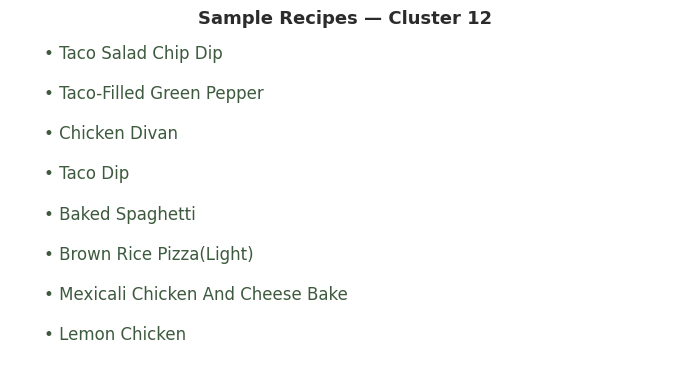

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.axis('off')

cluster_recipes = df[df['cluster'] == CLUSTER_ID]['title'].head(8).tolist()

for i, recipe in enumerate(cluster_recipes):
    ax.text(0.05, 1 - (i * 0.12), f"• {recipe}", fontsize=12,
            transform=ax.transAxes, verticalalignment='top', color='#3D5A3E')

ax.set_title(f'Sample Recipes — Cluster {CLUSTER_ID}', fontsize=13, 
             fontweight='bold', pad=15, color='#2b2b2b')

plt.tight_layout()
plt.savefig('cluster_recipes.png', dpi=150, bbox_inches='tight')
plt.show()

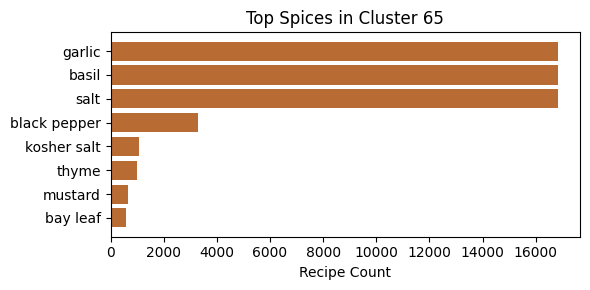

In [20]:
import matplotlib.pyplot as plt

spices, counts = zip(*top_spices)

plt.figure(figsize=(6, 3))
plt.barh(spices, counts, color='#B96B34')
plt.xlabel('Recipe Count')
plt.title(f'Top Spices in Cluster {CLUSTER_ID}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('cluster_visual.png', dpi=150)
plt.show()

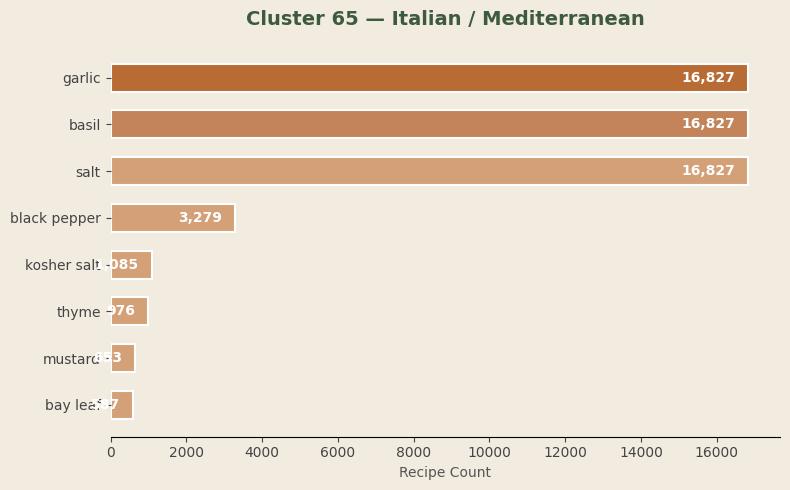

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

spices, counts = zip(*top_spices)
spices = list(spices)
counts = list(counts)

# Normalize bar widths for visual effect
max_count = max(counts)
norm_counts = [c / max_count for c in counts]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#F2EBE0')
ax.set_facecolor('#F2EBE0')

colors = ['#B96B34' if i == 0 else '#C4845A' if i == 1 else '#D4A078' for i in range(len(spices))]

bars = ax.barh(spices, counts, color=colors, height=0.6, edgecolor='white', linewidth=1.5)

# Add count labels inside bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() - max_count * 0.02, bar.get_y() + bar.get_height() / 2,
            f'{count:,}', va='center', ha='right', color='white', fontsize=10, fontweight='bold')

ax.set_xlim(0, max_count * 1.05)
ax.set_title(f'Cluster {CLUSTER_ID} — Italian / Mediterranean', 
             fontsize=14, fontweight='bold', color='#3D5A3E', pad=15)
ax.set_xlabel('Recipe Count', color='#555', fontsize=10)
ax.tick_params(colors='#444')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('cluster_visual.png', dpi=150, bbox_inches='tight')
plt.show()

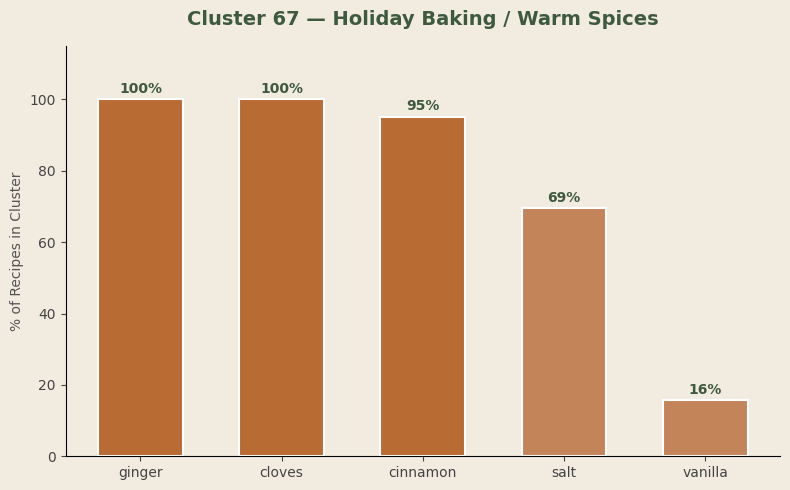

In [97]:
from collections import Counter
import matplotlib.pyplot as plt

CLUSTER_ID = 67

cluster_df = df[df['cluster'] == CLUSTER_ID]
total_recipes = len(cluster_df)

all_spices = []
for spice_list in cluster_df['spices']:
    all_spices.extend(eval(spice_list))

top_spices = Counter(all_spices).most_common(5)
spices, counts = zip(*top_spices)
percentages = [c / total_recipes * 100 for c in counts]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#F2EBE0')
ax.set_facecolor('#F2EBE0')

colors = ['#B96B34' if i < 3 else '#C4845A' if i < 5 else '#D4A078' for i in range(len(spices))]
bars = ax.bar(spices, percentages, color=colors, width=0.6, edgecolor='white', linewidth=1.5)

for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{pct:.0f}%', ha='center', va='bottom', color='#3D5A3E', fontsize=10, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_title(f'Cluster {CLUSTER_ID} — Holiday Baking / Warm Spices',
             fontsize=14, fontweight='bold', color='#3D5A3E', pad=15)
ax.set_ylabel('% of Recipes in Cluster', color='#555', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='x', colors='#444')
ax.tick_params(axis='y', colors='#444')

plt.tight_layout()
plt.savefig('cluster_visual.png', dpi=150, bbox_inches='tight')
plt.show()